# Feature Attribution using Ranking - v1.4

In [1]:
import sys

!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install catboost
!{sys.executable} -m pip install nbimporter
!{sys.executable} -m pip install tensorflow

In [2]:
import time
import numpy as np
import pandas as pd
import zipfile as zf
import nbimporter

import sklearn.ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
from catboost import CatBoostClassifier

from scipy.sparse.linalg import eigs

import networkx as nx
import GraphPR as gpr
import PageRank as pr

# Data preprocessing methods

In [3]:
# return one df without nan's on num_cols
# numerical features: fill nan's with median/mean/mode/zeros

def pre_proc_fillna_num_fts(df,num_cols,num_type='mean'):
    df_train= df.copy()

    if(num_type=='median'):
        for col in num_cols:
            ft_median= df_train[col].median()
            df_train[col]= df_train[col].fillna(ft_median)
    elif(num_type=='mode'):
        for col in num_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)
    elif(num_type=='zeros'):
        for col in num_cols:
            ft_zero= 0
            df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in num_cols:
            ft_mean= df_train[col].mean()
            df_train[col]= df_train[col].fillna(ft_mean)

    return df_train

In [4]:
# return one df without nan's on cat_cols
# categorical features: fill nan's with mode/mean/median/zeros

def pre_proc_fillna_cat_fts(df,cat_cols,cat_type='mode'):
    df_train= df.copy()
    
    if(cat_type!='mode' and type(df_train[cat_cols[0]].value_counts().index[0])!=type('str')):
        if(cat_type=='mean'):
            for col in cat_cols:
                ft_mean= df_train[col].mean()
                df_train[col]= df_train[col].fillna(ft_mean)
        elif(cat_type=='median'):
            for col in cat_cols:
                ft_median= df_train[col].median()
                df_train[col]= df_train[col].fillna(ft_median)
        elif(cat_type=='zeros'):
            for col in num_cols:
                ft_zero= 0
                df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in cat_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)

    return df_train

In [5]:
# selected_cols refers only to df's columns with numerical values
# if selected_cols is not defined as argument, all df columns will be normalized

def normalize_selected(df, selected_cols=[]):
    result= df.copy()
    
    if (len(selected_cols)== 0):
        selected_cols= df.columns
    
    for col in selected_cols:
        max_value= df[col].max()
        min_value= df[col].min()
        result[col]= (df[col]- min_value)/ (max_value - min_value)
        
    return result

In [6]:
# return a sorted DataFrame with Features and Importances - OHE compacted, that is, dataset's original features

def ft_importance_df(importances, ft_names, replace_list):
    fti= pd.Series(importances, index=ft_names).sort_values(ascending=False).to_frame().reset_index()
    fti= fti.rename(columns= {'index':'Feature',0:'Importance'}, inplace=False)
    fti['Feature'].replace(replace_list, inplace=True)
    fti= fti.groupby(['Feature']).sum().sort_values('Importance', ascending=False).reset_index()
    
    return fti

# Feature Attribution using Ranking - methods

In [7]:
# return a DataFrame with replaced values (mean/median/mode/zeros/none to categorical and numeric) 
# to fill train cols. df is post-processed (cat_cols encoded)

def replace_values(df,num_cols,num_type='mean',cat_type='none'):
    cat_values= None
    num_values= None
    
    if (cat_type=='mean'):
        cat_values= df.mean(axis=0).to_frame().T
    elif (cat_type=='median'):
        cat_values= df.median(axis=0).to_frame().T
    elif (cat_type=='mode'):
        cat_values= df.mode(axis=0)
    elif (cat_type=='zeros'):
        cat_values= df.loc[0:0,:].copy()
        cat_values.loc[:,:]= 0
    
    if (num_type=='mode'):
        num_values= df.mode(axis=0)
    elif (num_type=='median'):
        num_values= df.median(axis=0).to_frame().T
    elif (num_type=='mean'):
        num_values= df.mean(axis=0).to_frame().T
    elif (num_type=='zeros'):
        num_values= df.loc[0:0,:].copy()
        num_values.loc[:,:]= 0

    if(cat_type!='none'):
        cat_values[num_cols]= num_values[num_cols]
        return cat_values
    
    return num_values

In [8]:
# train the ML model and return its mean accuracy after n_train runs

def train_model_get_acc_mean(model, x_trn, x_tst, y_trn, y_tst, n_train):
    trainings= []
    
    np_ar= np.ndarray((0,0))    # model.fit() expect a 1d array instead of a pd.DataFrame
    pd_df= pd.DataFrame(np_ar)  # we need to verify and change it using values.ravel()
    
    if (type(y_trn)== type(pd_df)):
        
        for i in range(n_train):

            model.fit(x_trn, y_trn.values.ravel())
            acc= sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst))

            trainings.append(acc)
    else:
        for i in range(n_train):

            model.fit(x_trn, y_trn)
            acc= sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst))

            trainings.append(acc)
            
    return np.mean(trainings)

In [9]:
# re-training is needed because machine learning models typically assume that the train and the test data comes from a similar distribution 
# (Hooker et al., 2018)

# model is a NO trained model

# here we return p(x|i) and p(x|ij)
def remove_and_retrain(model, replace_ft_vals, x_trn, x_tst, y_trn, y_tst, n_train, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    n_fts= len(x_trn.columns)

    start= time.time()

    for i in range(n_fts):
        acc_row= []

        # replace the i-th ft with its respective mode/mean to "remove" it. train the ML model and get the mean accuracy
        train_copy_no_i= x_trn.copy()
        train_copy_no_i.loc[:,train_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        acc_no_i.append(train_model_get_acc_mean(model, train_copy_no_i, x_tst, y_trn, y_tst, n_train))

        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft with its respective mode/mean to "remove" it. here, we "remove" the i-th and the j-th ft
                # train the ML model and get the mean accuracy
                train_copy_no_ij= train_copy_no_i.copy()
                train_copy_no_ij.loc[:,train_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]

                acc_row.append(train_model_get_acc_mean(model, train_copy_no_ij, x_tst, y_trn, y_tst, n_train))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [10]:
# remove WITH NO retraining - to speedup and stability improvements
# model is a TRAINED model

# here we return p(x|i) and p(x|ij)
def remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    n_fts= len(x_tst.columns)

    start= time.time()
    
    np_ar= np.ndarray((0,0))    # model.fit() expect a 1d array instead of a pd.DataFrame
    pd_df= pd.DataFrame(np_ar)  # we need to verify and change it using values.ravel()
    

    for i in range(n_fts):  # remove and predict process to get gains/losses
        acc_row= []

        # replace the i-th ft of test set with its respective mode/mean to "remove" it. 
        x_tst_copy_no_i= x_tst.copy()
        x_tst_copy_no_i.loc[:,x_tst_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        acc_no_i.append(sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst_copy_no_i)))

        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft of test with its respective mode/mean to "remove" it. 
                # here, we "remove" the i-th and the j-th ft
                # test the ML model and get the mean accuracy
                x_tst_copy_no_ij= x_tst_copy_no_i.copy()
                x_tst_copy_no_ij.loc[:,x_tst_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]

                acc_row.append(sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst_copy_no_ij)))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [11]:
import math
from sklearn.neighbors import NearestNeighbors

# find the test_size nearest neighbors from a target_x instance
# return train, test, labels_train, labels_test datsets based on knn
# target_x and target_y are into testX and testY

def knn_train_test_split(df_x, df_y, target_x, target_y, test_size= 0.2):
    
    m_ins= df_x.shape[0] # m x n dataset

    neighbors= math.floor(test_size* m_ins)

    knn= NearestNeighbors(n_neighbors= neighbors)
    knn.fit(df_x)

    knn_index= knn.kneighbors(target_x, return_distance=False)
    
    trainX= df_x.drop(df_x.index[knn_index[0]])
    trainY= df_y.drop(df_y.index[knn_index[0]])

    testX= df_x.loc[df_x.index[knn_index[0]]]
    testY= df_y.loc[df_y.index[knn_index[0]]]

    testX= pd.concat([target_x, testX])
    testY= pd.concat([target_y, testY])
    
    return trainX, testX, trainY, testY

In [12]:
# find the neighb_size nearest neighbors from a target_x instance
# return data and target datsets based on knn
# with target_x and target_y into x_fts and y_trg

def knn_neighborhood(df_x, df_y, target_x, target_y, neighb_size= 0.2, target_in= True):
    
    m_ins= df_x.shape[0] # m x n dataset

    neighbors= math.floor(neighb_size* m_ins)

    knn= NearestNeighbors(n_neighbors= neighbors)
    knn.fit(df_x)

    knn_index= knn.kneighbors(target_x, return_distance=False)

    x_fts= df_x.loc[df_x.index[knn_index[0]]]
    y_trg= df_y.loc[df_y.index[knn_index[0]]]

    if (target_in== True):
        x_fts= pd.concat([target_x, x_fts])
        y_trg= pd.concat([target_y, y_trg])
    
    return x_fts, y_trg

In [13]:
# df_x and df_y doesn't contain target_x and target_y
# model is a a TRAINED model

# here we return p(x|i) and p(x|ij)
def knn_remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, target_x, target_y, 
                                neighb_size=0.01, verbose=False):
    
    start= time.time()

    m_ins= x_tst.shape[0] # m x n dataset
    n_fts= x_tst.shape[1]
    
    k_viz= math.floor(neighb_size* m_ins)
    k_viz_aux= math.floor(np.sqrt(m_ins))
    
    if (k_viz< k_viz_aux):
        k_viz= k_viz_aux
        
    # here, we generate a neighborhood of the target instance
    x_neighb, y_neighb= knn_neighborhood(x_tst, y_tst, target_x, target_y, neighb_size= (k_viz/ m_ins))    

    acc_no_i, acc_no_ij= remove_and_return_costs(model, replace_ft_vals, x_neighb, y_neighb)
    
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
    
    return acc_no_i, acc_no_ij

In [14]:
from sklearn.model_selection import KFold, StratifiedKFold

# df_x and df_y doesn't contain target_x and target_y
# model is a a TRAINED model

# here we return p(x|i) and p(x|ij)
def knnfold_remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, target_x, target_y, 
                                neighb_size=0.01, k_folds=5, verbose=False):
    
    start= time.time()

    m_ins= x_tst.shape[0] # m x n dataset
    n_fts= x_tst.shape[1]
    
    k_viz= math.floor(neighb_size* m_ins)
    k_viz_aux= math.floor(np.sqrt(m_ins))
    
    if (k_viz< k_viz_aux):
        k_viz= k_viz_aux
        
    # here, we generate a neighborhood of the target instance
    x_neighb, y_neighb= knn_neighborhood(x_tst, y_tst, target_x, target_y, 
                                         neighb_size= (k_viz/ m_ins), target_in= False) 
    

    K_folds= math.floor(np.sqrt(n_fts))

    if (K_folds< 5):
        K_folds= 5
        
    if (K_folds< k_folds):
        K_folds= k_folds   

    skf= StratifiedKFold(n_splits= K_folds, random_state=1234, shuffle=True)    
        
    acc_no_i= np.zeros(n_fts)
    acc_no_ij= np.zeros((n_fts,n_fts))
    
    for train_index, test_index in skf.split(x_neighb, y_neighb):
    
        x_fold= x_neighb.iloc[train_index]
        y_fold= y_neighb.iloc[train_index]
        
        # add the target instance on the fold set
        x_fold.append(target_x)
        y_fold.append(target_y)
    
        aux_acc_no_i, aux_acc_no_ij= remove_and_return_costs(model, replace_ft_vals, x_fold, y_fold)
    
        acc_no_i += aux_acc_no_i
        acc_no_ij += aux_acc_no_ij

    
    acc_no_i /= K_folds
    acc_no_ij /= K_folds
    
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
    
    return acc_no_i, acc_no_ij

# Costs matrix methods

In [15]:
# here we return | p(x|ij) - p(x|j) |

def get_p_matrix_v2(n_fts, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= np.abs(pij- pj)
                
    return p_matrix

In [16]:
# here we return (| p(x|ij) - p(x|j) | + | p(x|i) - p(x) |) / 2

def get_p_matrix_v3(n_fts, all_fts, no_i, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))
    p= all_fts

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= (np.abs(pij- pj)+ np.abs(pi- p))/ 2
                
    return p_matrix

In [17]:
# here we return (| p(x|ij) - p(x|i) | + | p(x|j) - p(x) |) / 2

def get_p_matrix_v4(n_fts, all_fts, no_i, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))
    p= all_fts

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= (np.abs(pij- pi)+ np.abs(pj- p))/ 2
                
    return p_matrix

# Stationary distribution methods

In [1591]:
# the stationary distribution is the fraction of time that the system spends in each state as the 
# number of samples approaches infinity
# it looks like there's not a built-in method to find the stationary distribution

# converts a matrix to a row stochastic matrix - a real square matrix, with each row summing to 1
def to_row_stochastic_matrix(M):
    result= (np.asarray(M)).copy()
    
    for row in result:
        n= sum(row)
        if (n> 0):
            row[:]= [f/sum(row) for f in row]
    
    return result

In [1526]:
# a stochastic matrix is a square matrix used to describe the transitions of a Markov chain 
# each of its entries is a nonnegative real number representing a probability
# a right (row) stochastic matrix is a real square matrix, with each row summing to 1

# if M is a row stochastic matrix, return TRUE

def check_row_stochastic_matrix(M):
    dim= M.shape
    
    if (dim[0]!= dim[1]):
        return False
    
    for row in M:
        n= sum(row)
        if (n< 0.99):
            return False
        
    return True

In [1693]:
# if M is a singular matrix, return TRUE

def singular_matrix(M):
    
    if not (np.linalg.cond(M) < 1/sys.float_info.epsilon):
        return True
            
    return False

In [1708]:
# the stationary distribution - analytical solution
# return 1D array

def stationary_dist_v1(stochastic_matrix):
    
    stationary= np.zeros(stochastic_matrix.shape[1])
    
    if (check_row_stochastic_matrix(stochastic_matrix)==False):
        return stationary
    
    size_A= stochastic_matrix.shape[1]
    ones= [1]* size_A

    A= np.append(np.transpose(stochastic_matrix)- np.identity(size_A),[ones],axis=0)

    v= np.zeros(size_A+ 1)
    v[size_A]= 1
    v= np.transpose(v)
    
    if (singular_matrix(np.transpose(A).dot(A))==True):
        return stationary

    try:
        stationary= np.linalg.solve(np.transpose(A).dot(A), np.transpose(A).dot(v))
    except:
        pass

    return stationary

In [1667]:
# the stationary distribution - another analytical solution
# return 1D array

def stationary_dist_v2(stochastic_matrix):
    
    stationary= np.zeros(stochastic_matrix.shape[1])
    
    if (check_row_stochastic_matrix(stochastic_matrix)==False):
        return stationary
    
    # we have to transpose so that Markov transitions correspond to right multiplying by a column vector
    eigval, eigvec= eigs(stochastic_matrix.T, k=1, which='LM')
    stationary= eigvec/ eigvec.sum()

    # eigs finds complex eigenvalues and eigenvectors, so you'll want the real part
    stationary= stationary.real

    # at the end we have to transpose the stationary vector to get a 1D array    
    return stationary.T[0]

In [1502]:
# convert a p_matrix to a right stochastic matrix - a real square matrix, with each row summing to 1

def p_matrix_to_row_stochastic_matrix(p_matrix):
    
    st_matrix= np.asarray(p_matrix)
    
    # now convert to right stochastic matrix
    st_matrix= to_row_stochastic_matrix(st_matrix)
    
    if (check_row_stochastic_matrix(st_matrix)==False):
        return np.zeros(st_matrix.shape)
    
    return st_matrix

In [1597]:
# find the stationary distribution
# return 1D array (version=1) or 2D array (version=1)

def p_matrix_to_stationary_dist(p_matrix, version=1):
    
    st_matrix= np.asarray(p_matrix)
    
    # now convert to right stochastic matrix
    st_matrix= to_row_stochastic_matrix(st_matrix)
    
    # then get the stationary distribution
    stationary_d= []
    
    if (version==1):
        stationary_d= stationary_dist_v1(st_matrix)
    else:
        stationary_d= stationary_dist_v2(st_matrix)
    
    return stationary_d

# New codes - Feature Attribution using Ranking

In [1141]:
# here we return our simplified shapley value for one variable regarding first row of Shapley powerset

def get_phi_i(n_fts, fi, f0): 
    
    phi_i= (1/ n_fts) * (fi- f0)
    
    return phi_i

In [24]:
def get_vector_phi_i(n_fts, full_ft, no_i):
    p_vector= np.zeros((n_fts))
    f0= full_ft
    
    for i in range(n_fts):
        fi= no_i[i]
        
        p_vector[i]= get_phi_i(n_fts, fi, f0)
        
    return p_vector

In [1142]:
# here we return our simplified shapley value for two variables regarding second row of Shapley powerset

def get_phi_ij(n_fts, fij, fi, fj, f0):
    
    first_term= (1/ n_fts) * (fi- f0)
    scond_term= (1/ (n_fts * (n_fts- 1))) * (2*fij- fi- fj)
    
    phi_ij= first_term+ scond_term
    
    return phi_ij

In [1428]:
def get_matrix_phi_ij(n_fts, full_ft, no_i, no_ij):
    phi_matrix= np.zeros((n_fts, n_fts))
    f0= full_ft

    for i in range(n_fts):
        fi= no_i[i]
        
        for j in range(n_fts):
            fj= no_i[j]
            
            if (i!= j):
                # there is no phi_ii in Shapley values
                fij= no_ij[i][j]
                
                phi_matrix[i][j]= get_phi_ij(n_fts, fij, fi, fj, f0)
        
    return phi_matrix    

In [1429]:
# here we return shapley values for phi_ij charged to phi_i and phi_j

def get_sh_p_matrix(n_fts, phi_i, phi_ij, mag=False, zeroDiag=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= phi_i[i]
        
        for j in range(n_fts):
            pij= phi_ij[i][j]

            # note that phi_ij computation include phi_i effect
            # then we subtract phi_i from phi_ij to get p_ij

            if (i!= j):
                if (mag==True):
                    p_matrix[i][j]= np.abs(pij- pi)
                else:
                    p_matrix[i][j]= (pij- pi)
            elif (i==j and zeroDiag==False):
                if (mag==True):
                    p_matrix[i][j]= np.abs(pi)
                else:
                    p_matrix[i][j]= pi
                
    return p_matrix

In [807]:
# here we return p(x|ij) - p(x|i)

def get_p_matrix_dif(n_fts, no_i, no_ij, f0= 0, remove=True, zeroDiag=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= pi- pij
            else:
                p_matrix[i][j]= pij- pi
            
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= f0- pi
                
    return p_matrix

In [808]:
# here we return | p(x|ij) - p(x|i) |

def get_p_matrix_mag(n_fts, no_i, no_ij, f0= 0, remove=True, zeroDiag=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= np.abs(pi- pij)
            else:
                p_matrix[i][j]= np.abs(pij- pi)
            
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= np.abs(f0- pi)
                
    return p_matrix

In [809]:
# here we return (p(x|ij) - p(x|i))^2

def get_p_matrix_div(n_fts, no_i, no_ij, f0= 0, remove=True, zeroDiag=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= np.power((pi- pij), 2)
            else:
                p_matrix[i][j]= np.power((pij- pi), 2)
            
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= np.power((f0- pi), 2)
                
    return p_matrix

In [810]:
# here we return the ratio p(x|ij) / p(x|i)

def get_p_matrix_ratio(n_fts, no_i, no_ij, f0= 0, remove=True, zeroDiag=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= (pi / pij)
            else:
                p_matrix[i][j]= (pij / pi)
            
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= f0 / pi
                
    return p_matrix

In [811]:
from scipy.spatial import distance

# here we return the euclidena distance between p(x|ij) and p(x|i)

def get_p_matrix_dist(n_fts, no_i, no_ij, f0= 0, remove=True, zeroDiag=True):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= np.sum(no_ij[i])
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            if (remove==True):
                p_matrix[i][j]= distance.euclidean(pi, pij)
            else:
                p_matrix[i][j]= distance.euclidean(pij, pi)
                
            if (zeroDiag==False and i==j):
                p_matrix[i][j]= distance.euclidean(f0, pi)
                
    return p_matrix

In [33]:
# The permutation feature importance algorithm based on Fisher, Rudin, and Dominici (2018):
# 
# Input: Trained model f, feature matrix X, target vector y, error measure L(y, f)
# 
# 1. Estimate the original model error e_org = L(y, f(X)) (e.g. mean squared error)
# 2. For each feature j in {1,...,p} do:
#    Generate feature matrix X_per by permuting feature j in the data X. 
#    This breaks the association between feature j and true outcome y.
#    Estimate error e_per = L(Y, f(X_per)) based on the predictions of the permuted data.
# Calculate permutation feature importance as quotient FIj = e_per / e_org or difference FIj = e_per - e_org
# Sort features by descending FI.

In [541]:
def get_dif_from_original(n_fts, e_org, e_per, remove=True):
    dim= len((np.asarray(e_per)).shape)
    
    if (dim== 1):
        e_vector= np.zeros(n_fts)
        
        if (remove==True):
            e_vector= e_org - e_per
        else:
            e_vector= e_per - e_org
        
        return e_vector
        
    elif (dim== 2):
        e_matrix= np.zeros((n_fts, n_fts))
    
        for i in range(n_fts):
            for j in range(n_fts):
                
                if (remove==True):
                    e_matrix[i][j]= (e_org - e_per[i][j])
                else:
                    e_matrix[i][j]= (e_per[i][j] - e_org)

        return e_matrix
    
    return None

In [542]:
from sklearn.metrics import mean_squared_error

# y real value from original p(f(x))
# 1D or 2D array of costs from no_i or no_ij
# return squared error 1D or 2D

def get_error(y, costs, mean_type=1):
   
    err_costs= np.asarray(costs)
    
    if (len(err_costs.shape)== 1):
        
        for i in range(err_costs.shape[0]):
            err_costs[i]= np.mean((y - err_costs[i])**(mean_type))
        
    elif (len(err_costs.shape)== 2):
        
        for i in range(err_costs.shape[0]):
            for j in range(err_costs.shape[1]):
                
                err_costs[i][j]= np.mean((y - err_costs[i][j])**(mean_type))
    
    return err_costs

In [35]:
from scipy.special import log_softmax
from scipy.special import softmax
np.set_printoptions(precision=5)

In [36]:
# Compute softmax values for each sets of scores in x
# x: numpy.ndarray, return numpy.ndarray
# x: pandas DataFrame, return pandas DataFrame

def my_softmax(x):
    
    npx= np.asarray(x)
    
    assert len(npx.shape)== 2
    s= np.max(npx, axis= 1)
    s= s[:, np.newaxis]
    e_x= np.exp(npx - s)
    div= np.sum(e_x, axis= 1)
    div= div[:, np.newaxis]
    
    result= e_x/ div
    
    dfx= pd.DataFrame(result)
    if (type(x)== type(dfx)):
        dfx.columns= x.columns
        return dfx
    
    return result

In [37]:
# normalize a numpy.ndarray to 0-1 range
# x: numpy.ndarray, return numpy.ndarray

def normalize(x):
    
    result= (x- np.min(x))/ (np.max(x)- np.min(x))
        
    return result

In [38]:
def translate_neg_vals(x):
    min_x= np.min(x)
    
    if (min_x< 0):
        x_t= x - min_x
        return x_t
    
    return x

In [39]:
def sigmoid(x):
    
    return 1 / (1 + np.exp(-x))

In [41]:
# Return E[X] the Expected Value of a model
# Than E[X] = V(O1)*P(O1) + V(O2)*P(O2) + ... + V(On)*P(On)
# E[X] is a linear combination of all possible outcomes associated with it
# We decompose each outcome, On, to a combination of the probability of that outcome, P(On),
# and its associated value, V(On).

# return the mean predicted probabilities, considering the predicted classes

def expected_value(model, x_train):
    
    # Expected value over the train data
    f_xi= model.predict(x_train)
    p_xi= model.predict_proba(x_train)

    tam= len(f_xi)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_xi[i][f_xi[i]]
        
    avg_pred= pred/ tam
    
    return avg_pred

In [40]:
from sklearn.metrics import confusion_matrix

# return the mean predicted probabilities, considering E[f(X)]= sum{i=1 to n}[f(xi)p(X= xi)]

def expected_value_v2(model, x_train):
    
    # Expected value over the train data
    f_xi= model.predict(x_train)
    p_xi= model.predict_proba(x_train)
    
    """
    # Alternative version using a confusion matrix - TODO
    y_pred= f_xi
    
    # y_true, y_pred
    tn, fp, fn, tp= confusion_matrix(x_train, y_pred).ravel()
    
    total= x_trn.shape[0]
    positives= tp + fn
    negatives= tn + fp
    
    p_rate= positives/ total
    n_rate= negatives/ total
    
    tpr= tp/ (tp + fn)
    tnr= tn/ (tn + fp)
    fpr= fp/ (tn + fp)
    fnr= fn/ (tp + fn)
    
    # v() function must to quantify a cost
    expect_value= p_rate* (tpr* v(tpr) + fnr* v(fnr)) + 
                  n_rate* (tnr* v(tnr) + fpr* v(fpr))    
    """
    
    tam= len(f_xi)
    pred= 0
    num_trues= 0
    
    for i in range(tam):
        pred= pred+ (f_xi[i] * p_xi[i][f_xi[i]])
        
        if (f_xi[i]==1):
            num_trues= num_trues+1
        
    avg_pred= pred/ num_trues
    
    return avg_pred

In [193]:
def reg_expected_value(model, x_train):
    
    # Expected value over the train data
    f_xi= model.predict(x_train)

    tam= len(f_xi)
    pred= 0
    
    for i in range(tam):
        pred= pred+ f_xi[i]
        
    avg_pred= pred/ tam
    
    return avg_pred

In [42]:
# return the mean predicted probabilities, considering the informed class labels

def get_avg_pred_proba(model, x_data, y_data):
    
    f_xi= model.predict(x_data)
    p_xi= model.predict_proba(x_data)
        
    assert len(y_data)== len(f_xi), "Same size parameters expected to x and y"
    
    tam= len(f_xi)
    pred= 0
    
    for i in range(tam):
        pred= pred+ p_xi[i][y_data[i]]
        
    avg_pred= pred/ tam

    return avg_pred

In [43]:
# remove WITH NO retraining - to speedup and stability improvements
# model is a TRAINED classifier model

# NEW VERSION based on class predicted probabilities

# here we return p(x|i) and p(x|ij)
def remove_and_gen_costs(model, n_fts, replace_ft_vals, x_to_exp, y_true, use_preds= True, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    start= time.time()
    
    f_x= model.predict(x_to_exp)

    for i in range(n_fts):  # remove and predict process to get gains/losses
        acc_row= []

        # replace the i-th ft of test set with its respective mode/mean to "remove" it.
        x_to_exp_copy_no_i= x_to_exp.copy()
        x_to_exp_copy_no_i.loc[:,x_to_exp_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        # if True, predicted class labels f_x are used. If false, the true labels from y_true are used
        if (use_preds== True):
            acc_no_i.append(get_avg_pred_proba(model, x_to_exp_copy_no_i, f_x))
        else:
            acc_no_i.append(get_avg_pred_proba(model, x_to_exp_copy_no_i, y_true.values.ravel().astype(int)))
        
        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft of test with its respective mode/mean to "remove" it. 
                # here, we "remove" the j-th ft considering we have the i-th ft removed before
                # test the ML model and get the mean accuracy
                x_to_exp_copy_no_ij= x_to_exp_copy_no_i.copy()
                x_to_exp_copy_no_ij.loc[:,x_to_exp_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]
                
                # if True, predicted class labels are used. If false, the true labels from y_true are used
                if (use_preds== True):
                    acc_row.append(get_avg_pred_proba(model, x_to_exp_copy_no_ij, f_x))
                else:
                    acc_row.append(get_avg_pred_proba(model, x_to_exp_copy_no_ij, 
                                                      y_true.values.ravel().astype(int)))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [794]:
# remove WITH NO retraining - to speedup and stability improvements
# model is a TRAINED regressor model

# here we return p(x|i) and p(x|ij)
def remove_and_gen_costs_reg(model, n_fts, replace_ft_vals, x_to_exp, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    start= time.time()

    for i in range(n_fts):  # add and predict process to get gains/losses
        acc_row= []

        # replace the i-th ft of test set with its respective mode/mean to "remove" it.
        x_to_exp_copy_no_i= x_to_exp.copy()
        x_to_exp_copy_no_i.loc[:,x_to_exp_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]
        
        acc_no_i.append(model.predict(x_to_exp_copy_no_i)[0])
        
        for j in range(n_fts):
            
            if (i<= j):
                # replace the j-th ft of test with its respective mode/mean to "remove" it. 
                # here, we "remove" the j-th ft considering we have the i-th ft removed before
                # test the ML model and get the mean accuracy
                x_to_exp_copy_no_ij= x_to_exp_copy_no_i.copy()
                x_to_exp_copy_no_ij.loc[:,x_to_exp_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]
                
                acc_row.append(model.predict(x_to_exp_copy_no_ij)[0])
                
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])
        
        acc_no_ij.append(acc_row)
        
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [194]:
# add WITH NO retraining - to speedup and stability improvements
# model is a TRAINED regressor model

# here we return p(x|i) and p(x|ij)
def add_and_gen_costs_reg(model, n_fts, replace_ft_vals, x_to_exp, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    start= time.time()

    for i in range(n_fts):  # add and predict process to get gains/losses
        acc_row= []

        # replace_ft_vals contains "neutral" values to each feature, then we add the i-th value 
        # from x_to_exp one by one the assess gain/loses
        x_to_exp_with_i= replace_ft_vals.copy()
        x_to_exp_with_i.loc[:,x_to_exp_with_i.columns[i]]= x_to_exp.iloc[0,i]
        
        acc_no_i.append(model.predict(x_to_exp_with_i)[0])
        
        for j in range(n_fts):

            # x_to_exp_with_i contains replace_ft_vals "neutral" values to each feature except in i-th position
            # then we also add the j-th value from x_to_exp one by one the assess gain/loses
            x_to_exp_with_ij= x_to_exp_with_i.copy()
            x_to_exp_with_ij.loc[:,x_to_exp_with_ij.columns[j]]= x_to_exp.iloc[0,j]

            acc_row.append(model.predict(x_to_exp_with_ij)[0])

        acc_no_ij.append(acc_row)
        
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [45]:
# receive the feature ranking vector sum its abs values and return a regularized version

def ft_ranking_regularization(ft_ranking):
    tam_fts= len(ft_ranking)

    fator= 0

    for i in range(tam_fts):
        fator= fator+ np.abs(ft_ranking[i])

    ft_ranking_reg= []

    #if (fator> 1):
    ft_ranking_reg= ft_ranking/ fator
    #else:
    #    ft_ranking_reg= ft_ranking/ 1
        
    return ft_ranking_reg

In [1272]:
# split p_matrix into two new matrix, a positive and a negative
# return the positive and the negative values from p_matrix

def split_pos_neg_p_matrix(n_fts, p_matrix):

    pos_p_matrix= np.zeros((n_fts, n_fts))
    neg_p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        for j in range(n_fts):

            if (p_matrix[i][j]< 0):
                neg_p_matrix[i][j]= p_matrix[i][j]
            else:
                pos_p_matrix[i][j]= p_matrix[i][j]
            
    return pos_p_matrix, neg_p_matrix

In [1334]:
# transform FAR information into SHAP explanation data

import shap
shap.initjs()

def to_sh_exp(explain_vals, base_prob, inst_vals, ft_names):

    sh_exp= shap.Explanation(values=explain_vals, base_values=base_prob, data=inst_vals, 
                             feature_names= np.asarray(ft_names).tolist())

    return sh_exp

# Tests

In [98]:
import synthetic_data as syn

synth= syn.synthetic_data_generator(n=500,df=True)

# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.297434,1.480258,-1.047823,-1.235156
1,-2.255077,1.190942,-0.573914,-3.008057
2,-3.336307,3.258936,-0.030324,-0.361786
3,0.672172,1.928683,-0.456206,-3.051892
4,-1.106266,3.345063,-3.481175,-1.105859


In [228]:
print(np.round(synth.memory_usage().sum() / 10**6, 2), "MB")

0.04 MB


In [99]:
soft_x_syn= pd.DataFrame(softmax(np.asarray(x_syn)), columns=x_syn.columns)

soft_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.000010,0.000168,0.000013,0.000011
1,0.000004,0.000126,0.000022,0.000002
2,0.000001,0.000995,0.000037,0.000027
3,0.000075,0.000263,0.000024,0.000002
4,0.000013,0.001084,0.000001,0.000013


In [100]:
# Normalization
from sklearn.preprocessing import MinMaxScaler

# All dataset is numeric
#scaler= MinMaxScaler(feature_range=(0, 1))
#norm_x_syn= scaler.fit_transform(np.asarray(x_syn))
#norm_x_syn= pd.DataFrame(norm_x_syn, columns=x_syn.columns)

norm_x_syn= normalize_selected(x_syn)

norm_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.425977,0.626863,0.368465,0.345838
1,0.359321,0.603430,0.427822,0.123927
2,0.284062,0.770929,0.495906,0.455156
3,0.563072,0.663184,0.442565,0.118440
4,0.439284,0.777905,0.063690,0.362022


In [101]:
# Standarization
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler().fit(np.asarray(x_syn))
# realiza a padronização (média= 0, variância= 1)
stand_x_syn= scaler.transform(np.asarray(x_syn))
stand_x_syn= pd.DataFrame(stand_x_syn, columns=x_syn.columns)

stand_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-0.103626,0.267269,-0.428075,-0.498028
1,-0.577271,0.116797,-0.225488,-1.265198
2,-1.112041,1.192347,0.006886,-0.120102
3,0.870530,0.500491,-0.175170,-1.284166
4,-0.009076,1.237141,-1.468284,-0.442078


In [102]:
from scipy.stats.contingency import margins

x_mg, y_mg= margins(np.asarray(norm_x_syn))

y_mg/ norm_x_syn.shape[0]

array([[0.44056, 0.58524, 0.49389, 0.4899 ]])

In [103]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(norm_x_syn,y_syn,
                                                                                 train_size=0.80,
                                                                                 random_state=1234)

xgb_model= xgb.XGBRFClassifier(learning_rate= 0.01,
                               n_estimators= 500,
                               max_depth= 6,
                               gamma= 1,
                               objective= 'binary:logistic',
                               eval_metric='logloss',
                               use_label_encoder=False)

eval_set= [(train, labels_train), (test, labels_test)]
eval_metric= ["auc","error"]

xgb_model.fit(train, labels_train, eval_metric=eval_metric, eval_set=eval_set, verbose=False)

acc_all= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))
acc_all

0.96

In [795]:
from sklearn.metrics import mean_absolute_error

xgb_regre= xgb.XGBRegressor(
        learning_rate= 0.01,
        n_estimators= 500,
        max_depth= 6,
        gamma= 1,
        tree_method="hist",
        eval_metric=mean_absolute_error,
)

xgb_regre.fit(train, labels_train, eval_set=[(test, labels_test)], verbose=False)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             eval_metric=<function mean_absolute_error at 0x7f72c357c040>,
             gamma=1, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.01, max_delta_step=0,
             max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=500, n_jobs=4,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, scale_pos_weight=1, subsample=1, tree_method='hist',
             validate_parameters=1, verbosity=None)

In [104]:
prob_mean_class= get_avg_pred_proba(xgb_model, train, labels_train.values.ravel().astype(int))
prob_mean_class

0.5045739778876305

In [105]:
exp_value= expected_value(xgb_model, train)
exp_value

0.5046651735156774

In [106]:
# average values to replace as neutral values the feature values (from entire dataset)

replace_ft= replace_values(norm_x_syn, norm_x_syn.columns, num_type='mean')
replace_ft

,core_1,core_2,noise_1,noise_2
0,0.440561,0.58524,0.493889,0.489897


In [107]:
replace_ft_zero= replace_values(norm_x_syn, norm_x_syn.columns, num_type='zeros')
replace_ft_zero

,core_1,core_2,noise_1,noise_2
0,0.0,0.0,0.0,0.0


In [108]:
exp_mean_ft= expected_value(xgb_model, replace_ft)
exp_mean_ft

0.5049099326133728

In [109]:
exp_zero_ft= expected_value(xgb_model, replace_ft_zero)
exp_zero_ft

0.5040869116783142

In [110]:
xgb_model.predict(replace_ft)

array([1])

In [111]:
xgb_model.predict_proba(replace_ft)

array([[0.49509, 0.50491]], dtype=float32)

In [1464]:
# the instance to be explained (from train dataset)

target_pos= 1

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

target_inst

,core_1,core_2,noise_1,noise_2
42,0.466194,0.721861,0.948764,0.04446


In [1025]:
# the instance to be explained (from train dataset)

target_pos2= 9 # A DIFFERENT INSTANCE WAS TAKEN HERE

target_inst2= train.iloc[target_pos2].to_frame().T
target_labl2= labels_train.iloc[target_pos2].to_frame().T

target_inst2

,core_1,core_2,noise_1,noise_2
845,0.46423,0.331611,0.465974,0.769212


In [1023]:
train.head()

,core_1,core_2,noise_1,noise_2
281,0.139542,0.715691,0.352192,0.672052
42,0.466194,0.721861,0.948764,0.044460
255,0.473301,0.653833,0.871313,0.940102
906,0.283228,0.169846,0.287957,0.633027
394,0.487777,0.658093,0.107913,0.141769


In [912]:
xgb_model.predict(target_inst)

array([1])

In [913]:
p_pred_target= get_avg_pred_proba(xgb_model, target_inst, xgb_model.predict(target_inst))

p_pred_target

0.5049512982368469

In [914]:
exp_target= expected_value(xgb_model, target_inst)

exp_target

0.5049512982368469

In [915]:
# Overall expected prediction value (or base value). 
# That can be understood as the average model output across the training set

p_base_value= get_avg_pred_proba(xgb_model, train, xgb_model.predict(train))

p_base_value

0.5046651735156774

In [1029]:
# get the model behavior after removing process of i (single ft) and ij (pair)

num_fts= len(x_syn.columns)

acc_no_i, acc_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft, target_inst, target_labl, 
                                          use_preds= True, verbose=True)

--- 0.3 seconds ---


In [1030]:
# data from the second instance to be explained

acc_no_i2, acc_no_ij2= remove_and_gen_costs(xgb_model, num_fts, replace_ft, target_inst2, target_labl2, 
                                          use_preds= True, verbose=True)

--- 0.35 seconds ---


In [1031]:
# REGRESSION VERSION
# get the model behavior after removing process of i (single ft) and ij (pair)

acc_no_i_reg, acc_no_ij_reg= remove_and_gen_costs_reg(xgb_regre, num_fts, replace_ft, target_inst, 
                                                      verbose=True)

--- 0.13 seconds ---


In [1032]:
acc_no_i_reg2, acc_no_ij_reg2= remove_and_gen_costs_reg(xgb_regre, num_fts, replace_ft, target_inst2, 
                                                      verbose=True)

--- 0.16 seconds ---


In [1033]:
print(acc_no_i)
print(acc_no_i2)

[0.5049687027931213, 0.5040266513824463, 0.5049499869346619, 0.5049512982368469]
[0.5049132108688354, 0.49590712785720825, 0.5049026012420654, 0.5049028396606445]


In [1034]:
print(acc_no_i_reg)
print(acc_no_i_reg2)

[0.9426754, 0.8305637, 0.9426754, 0.9426754]
[0.06563888, 0.8305637, 0.06472042, 0.06472042]


In [1035]:
for i in range(num_fts):
    print(acc_no_ij[i])
    
print("")

for i in range(num_fts):
    print(acc_no_ij2[i])

[0.5049687027931213, 0.5049021244049072, 0.5049690008163452, 0.5049687027931213]
[0.5049021244049072, 0.5040266513824463, 0.504026472568512, 0.5041036605834961]
[0.5049690008163452, 0.504026472568512, 0.5049499869346619, 0.5049499869346619]
[0.5049687027931213, 0.5041036605834961, 0.5049499869346619, 0.5049512982368469]

[0.5049132108688354, 0.4950900673866272, 0.5049132108688354, 0.5049135684967041]
[0.4950900673866272, 0.49590712785720825, 0.49590712785720825, 0.49589645862579346]
[0.5049132108688354, 0.49590712785720825, 0.5049026012420654, 0.5049028396606445]
[0.5049135684967041, 0.49589645862579346, 0.5049028396606445, 0.5049028396606445]


In [1036]:
for i in range(num_fts):
    print(acc_no_ij_reg[i])
    
print("")

for i in range(num_fts):
    print(acc_no_ij_reg2[i])

[0.9426754, 0.9379865, 0.9426754, 0.9426754]
[0.9379865, 0.8305637, 0.8305637, 0.8305637]
[0.9426754, 0.8305637, 0.9426754, 0.9426754]
[0.9426754, 0.8305637, 0.9426754, 0.9426754]

[0.06563888, 0.9379865, 0.06563888, 0.06563888]
[0.9379865, 0.8305637, 0.8305637, 0.8305637]
[0.06563888, 0.8305637, 0.06472042, 0.06472042]
[0.06563888, 0.8305637, 0.06472042, 0.06472042]


In [1037]:
# relative to target_inst only

dif_no_i= get_dif_from_original(num_fts, p_pred_target, acc_no_i)
dif_no_ij= get_dif_from_original(num_fts, p_pred_target, acc_no_ij)

dif_ij

array([[ 1.06096e-05, -9.81253e-03,  1.06096e-05,  1.09673e-05],
       [-9.81253e-03, -8.99547e-03, -8.99547e-03, -9.00614e-03],
       [ 1.06096e-05, -8.99547e-03,  0.00000e+00,  2.38419e-07],
       [ 1.09673e-05, -9.00614e-03,  2.38419e-07,  2.38419e-07]])

In [1038]:
# relative to target_inst only

err_no_i= get_error(p_base_value, acc_no_i)
err_no_ij= get_error(p_base_value, acc_no_ij)

err_no_ij

array([[-0.0003 , -0.00024, -0.0003 , -0.0003 ],
       [-0.00024,  0.00064,  0.00064,  0.00056],
       [-0.0003 ,  0.00064, -0.00028, -0.00028],
       [-0.0003 ,  0.00056, -0.00028, -0.00029]])

In [917]:
xgb_model.feature_importances_

array([0.43301, 0.51833, 0.02535, 0.02331], dtype=float32)

# Tests using SHAP

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


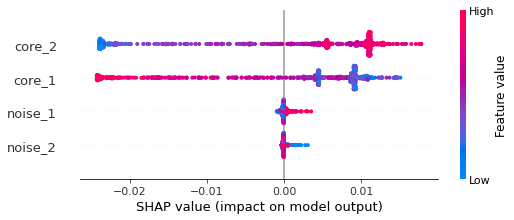

In [1039]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [923]:
shap.plots.force(shap_values[target_pos])

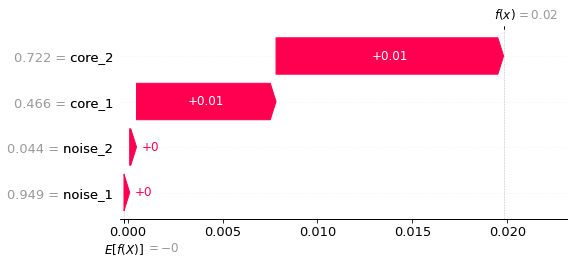

In [1040]:
shap.plots.waterfall(shap_values[target_pos])

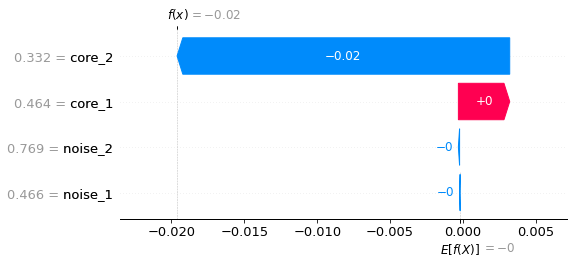

In [1041]:
shap.plots.waterfall(shap_values[target_pos2])

# FAR Magnitude

In [1042]:
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_mag= p_matrix_to_stationary_dist(p_matrix_mag)

ft_ranking= pd.Series(stationary_mag, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.498520
core_1     0.458982
noise_2    0.040298
noise_1    0.002200
dtype: float64

In [1043]:
p_matrix_mag

array([[0.00000e+00, 6.65784e-05, 2.98023e-07, 0.00000e+00],
       [8.75473e-04, 0.00000e+00, 1.78814e-07, 7.70092e-05],
       [1.90139e-05, 9.23514e-04, 0.00000e+00, 0.00000e+00],
       [1.74046e-05, 8.47638e-04, 1.31130e-06, 0.00000e+00]])

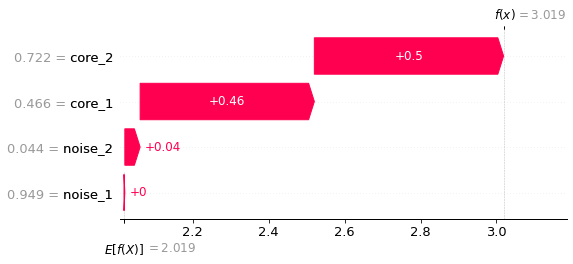

In [1044]:
sh_test= to_sh_exp(stationary_mag, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

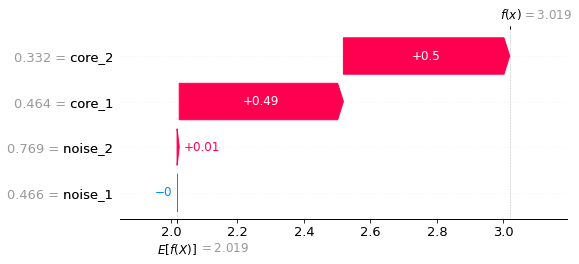

In [1046]:
# RELATIVE TO target_inst2
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag2= get_p_matrix_mag(num_fts, acc_no_i2, acc_no_ij2)

# get the stationary distribution
stationary_mag2= p_matrix_to_stationary_dist(p_matrix_mag2)

sh_test= to_sh_exp(stationary_mag2, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

# Divergence (similar to magnitude, target_inst only)

In [1047]:
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
p_matrix_div= get_p_matrix_div(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_div= p_matrix_to_stationary_dist(p_matrix_div)

ft_ranking= pd.Series(stationary_div, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499994
core_1     0.496157
noise_2    0.003839
noise_1    0.000010
dtype: float64

In [1048]:
p_matrix_div

array([[0.00000e+00, 4.43268e-09, 8.88178e-14, 0.00000e+00],
       [7.66453e-07, 0.00000e+00, 3.19744e-14, 5.93042e-09],
       [3.61528e-10, 8.52879e-07, 0.00000e+00, 0.00000e+00],
       [3.02919e-10, 7.18490e-07, 1.71951e-12, 0.00000e+00]])

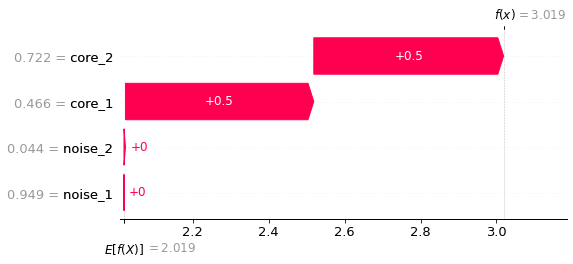

In [1049]:
sh_test= to_sh_exp(stationary_div, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Difference

In [1050]:
# test considering p_matrix generated from no_i no_ij difference

# get the probability matrix
p_matrix_dif= get_p_matrix_dif(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_dif= p_matrix_to_stationary_dist(p_matrix_dif)

ft_ranking= pd.Series(stationary_dif, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.503131
noise_2    0.143395
noise_1    0.142921
core_1     0.138067
dtype: float64

In [1051]:
p_matrix_dif

array([[ 0.00000e+00,  6.65784e-05, -2.98023e-07,  0.00000e+00],
       [-8.75473e-04,  0.00000e+00,  1.78814e-07, -7.70092e-05],
       [-1.90139e-05,  9.23514e-04,  0.00000e+00,  0.00000e+00],
       [-1.74046e-05,  8.47638e-04,  1.31130e-06,  0.00000e+00]])

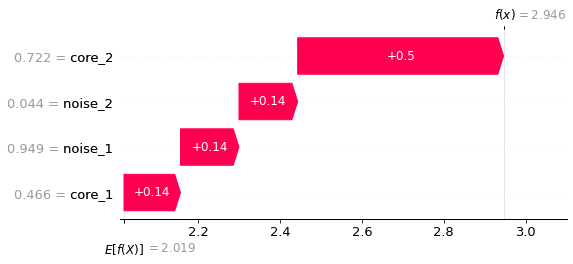

In [1052]:
sh_test= to_sh_exp(stationary_dif, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

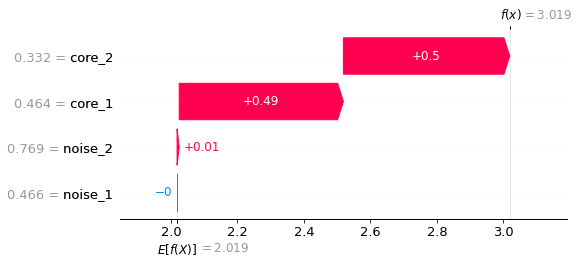

In [1053]:
# RELATIVE TO target_inst2
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_dif2= get_p_matrix_dif(num_fts, acc_no_i2, acc_no_ij2)

# get the stationary distribution
stationary_dif2= p_matrix_to_stationary_dist(p_matrix_dif2)

sh_test= to_sh_exp(stationary_dif2, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

# Split costs from difference - negative and positive values

In [1054]:
pos, neg= split_pos_neg_p_matrix(num_fts, p_matrix_dif)

pos2, neg2= split_pos_neg_p_matrix(num_fts, p_matrix_dif2)

pos

array([[0.00000e+00, 6.65784e-05, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 1.78814e-07, 0.00000e+00],
       [0.00000e+00, 9.23514e-04, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 8.47638e-04, 1.31130e-06, 0.00000e+00]])

In [966]:
neg

array([[ 0.00000e+00,  0.00000e+00, -2.98023e-07,  0.00000e+00],
       [-8.75473e-04,  0.00000e+00,  0.00000e+00, -7.70092e-05],
       [-1.90139e-05,  0.00000e+00,  0.00000e+00,  0.00000e+00],
       [-1.74046e-05,  0.00000e+00,  0.00000e+00,  0.00000e+00]])

In [1056]:
p_matrix_dif_diag = p_matrix_dif.copy()
p_matrix_dif_diag2= p_matrix_dif2.copy()

for i in range(num_fts):
    p_matrix_dif_diag[i][i]= err_no_i[i]
    p_matrix_dif_diag2[i][i]= err_no_i[i]

pos_diag, neg_diag= split_pos_neg_p_matrix(num_fts, p_matrix_dif_diag)
pos_diag2, neg_diag2= split_pos_neg_p_matrix(num_fts, p_matrix_dif_diag2)

p_matrix_dif_diag

array([[-3.03529e-04,  6.65784e-05, -2.98023e-07,  0.00000e+00],
       [-8.75473e-04,  6.38522e-04,  1.78814e-07, -7.70092e-05],
       [-1.90139e-05,  9.23514e-04, -2.84813e-04,  0.00000e+00],
       [-1.74046e-05,  8.47638e-04,  1.31130e-06, -2.86125e-04]])

In [1057]:
# get the stationary distribution positive
pos_stationary= p_matrix_to_stationary_dist(pos)

pos_ft_ranking= pd.Series(pos_stationary, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_2     0.5
noise_1    0.5
core_1     0.0
noise_2    0.0
dtype: float64

In [1058]:
# get the stationary distribution positive
pos_stationary2= p_matrix_to_stationary_dist(pos2)

pos_ft_ranking= pd.Series(pos_stationary2, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_2     5.000000e-01
core_1     4.935551e-01
noise_2    6.444877e-03
noise_1    5.192979e-18
dtype: float64

In [1059]:
# get the stationary distribution positive
pos_stationary_diag= p_matrix_to_stationary_dist(pos_diag)

pos_ft_ranking= pd.Series(pos_stationary_diag, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_2     9.997201e-01
noise_1    2.798867e-04
core_1     3.700743e-17
noise_2    7.480995e-18
dtype: float64

In [1060]:
# get the stationary distribution positive
pos_stationary_diag2= p_matrix_to_stationary_dist(pos_diag2)

pos_ft_ranking= pd.Series(pos_stationary_diag2, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_2     6.391733e-01
core_1     3.561757e-01
noise_2    4.650967e-03
noise_1    1.876368e-17
dtype: float64

In [1061]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary= p_matrix_to_stationary_dist(np.abs(neg)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     5.000000e-01
noise_1    5.000000e-01
noise_2    3.966145e-17
core_2    -3.896623e-17
dtype: float64

In [1062]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary2= p_matrix_to_stationary_dist(np.abs(neg2)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary2, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     5.000000e-01
noise_2    5.000000e-01
core_2     1.608773e-16
noise_1   -4.676948e-17
dtype: float64

In [1063]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary_diag= p_matrix_to_stationary_dist(np.abs(neg_diag)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary_diag, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     9.845679e-01
noise_1    1.543210e-02
core_2     5.424592e-16
noise_2   -2.000974e-14
dtype: float64

In [1064]:
# get the stationary distribution - NEGATIVE SIDE
neg_stationary_diag2= p_matrix_to_stationary_dist(np.abs(neg_diag2)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary_diag2, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     9.684650e-01
noise_2    3.153501e-02
core_2    -5.634161e-17
noise_1   -2.857119e-14
dtype: float64

# Exp target_inst with no diagonal elements in p_matrix

In [1264]:
st_final= merge_pos_neg_stationary(pos_stationary, neg_stationary, stationary_mag, merge_type="mean")

ft_ranking= pd.Series(st_final, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.332840
noise_2    0.013433
noise_1    0.000733
core_1    -0.013673
dtype: float64

In [1265]:
st_final_reg= ft_ranking_regularization(st_final)

ft_ranking_reg= pd.Series(st_final_reg, index=train.columns).sort_values(ascending=False)
ft_ranking_reg

core_2     0.922816
noise_2    0.037243
noise_1    0.002033
core_1    -0.037908
dtype: float64

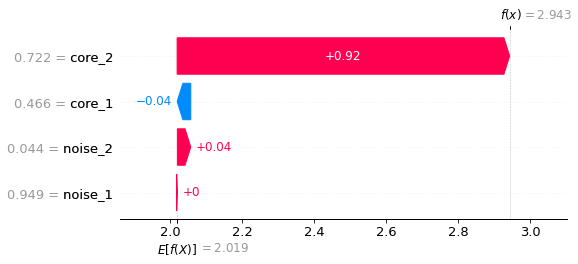

In [1266]:
sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_exp)

# Exp target_inst with diagonal elements in p_matrix

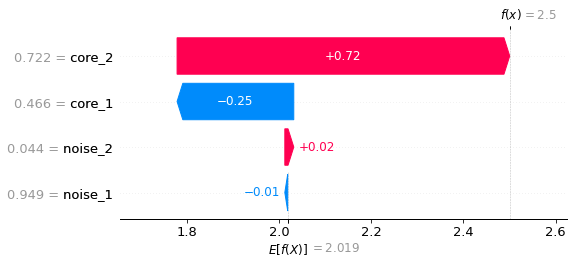

In [1268]:
st_final= merge_pos_neg_stationary(pos_stationary_diag, neg_stationary_diag, stationary_mag, merge_type="mean")

st_final_reg= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_exp)

# Exp target_inst2 with no diagonal elements in p_matrix

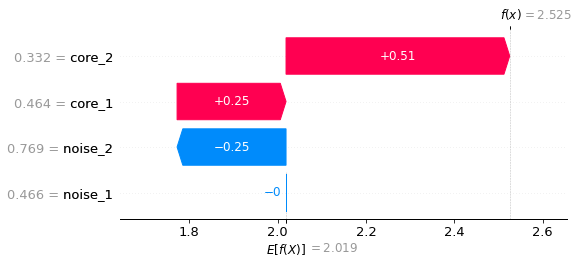

In [1263]:
st_final= merge_pos_neg_stationary(pos_stationary2, neg_stationary2, stationary_mag2, merge_type="mean")

st_final_reg= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_exp)

# Exp target_inst2 with diagonal elements in p_matrix

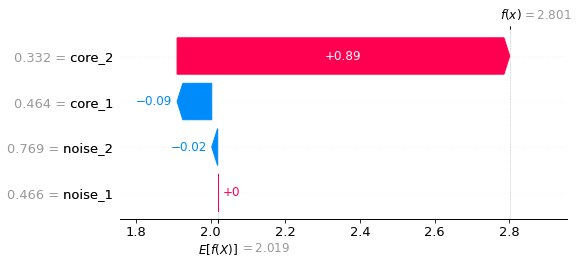

In [1270]:
st_final= merge_pos_neg_stationary(pos_stationary_diag2, neg_stationary_diag2, stationary_mag2, merge_type="mean")

st_final_reg= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_exp)

In [1718]:
# model is a treined classifier
# data is a preprocessed Pandas DataFrame -- model's training data
# labels are the data labels
# target is an integer indicating the position on data related to the instance to be explained
# replace_type is the type of transformation related to the numerical colums of data

# RETURN the target instance stationary distribution, its Feature Attribution Ranking explanation and 
#        a SHAP formatted explanation -- It is a local explanation

def far_explainer(model, data, labels, target, replace_type="mean", merge_type="mean", 
                  zeroDiag=True, regularization=True, shapley=False, verbose=False):
    
    start= time.time()
    
    n_fts= len(data.columns)
    
    target_i= data.iloc[target].to_frame().T
    target_l= labels.iloc[target].to_frame().T
    
    replace_ft= replace_values(data, data.columns, num_type=replace_type, cat_type='none')
    
    expected_val= get_avg_pred_proba(model, data, model.predict(data))
    
    # classifier and removing-based explanation
    no_i, no_ij= remove_and_gen_costs(model, n_fts, replace_ft, target_i, target_l, 
                                      use_preds=True, verbose=False)
    
    if (shapley==False):
        # get the probability matrix - MAGNITUDE
        p_matrix_mag= get_p_matrix_mag(n_fts, no_i, no_ij, f0=expected_val, remove=True, zeroDiag=zeroDiag)
        # get the stationary distribution - MAGNITUDE
        stationary_mag= p_matrix_to_stationary_dist(p_matrix_mag, version=1)

        # get the probability matrix - DIFFERENCE
        p_matrix_dif= get_p_matrix_dif(n_fts, no_i, no_ij, f0=expected_val, remove=True, zeroDiag=zeroDiag)
        # get the stationary distribution - DIFFERENCE
        #stationary_dif= p_matrix_to_stationary_dist(p_matrix_dif, version=1)
    else:
        # get the first row shapley values to fi
        sh_phi_i= get_vector_phi_i(n_fts, expected_val, no_i)
        
        # get the second row shapley values to fij
        sh_phi_ij= get_matrix_phi_ij(n_fts, expected_val, no_i, no_ij)
        
        # get the probability matrix magnitude between fij and fi
        p_matrix_mag= get_sh_p_matrix(n_fts, sh_phi_i, sh_phi_ij, mag=True, zeroDiag=zeroDiag)
        # get the stationary distribution - FROM MAG VALUES
        stationary_mag= p_matrix_to_stationary_dist(p_matrix_mag, version=1)
        
        # get the probability matrix difference between fij and fi
        p_matrix_dif= get_sh_p_matrix(n_fts, sh_phi_i, sh_phi_ij, mag=False, zeroDiag=zeroDiag)
        
    
    # split between positive and negative costs from difference p_matrix
    pos, neg= split_pos_neg_p_matrix(n_fts, p_matrix_dif)
    
    # get the stationary distribution - POSITIVE
    pos_stationary= p_matrix_to_stationary_dist(pos, version=1)
    
    # get the stationary distribution - NEGATIVE
    neg_stationary= p_matrix_to_stationary_dist(np.abs(neg), version=1) # note abs use
    
    stationary_final= merge_pos_neg_stationary(pos_stationary, neg_stationary, stationary_mag, 
                                               merge_type=merge_type)
    
    if (regularization==True):
        stationary_final= ft_ranking_regularization(stationary_final)

    ft_ranking= pd.Series(stationary_final, index=data.columns).sort_values(ascending=False)
    
    sh_exp= to_sh_exp(stationary_final, 1/(1-expected_val), np.asarray(target_i)[0], target_i.columns)
    
    if (verbose==True):
        print("Target instance: ")
        print(target_i)
        print("\nNo i classifier run: ")
        print(no_i)
        print("\nNo ij classifier run: ")
        print(np.asarray(no_ij))
        print("\nDifference p_matrix: ")
        print(p_matrix_dif)
        print("\nFeature importances form magnitude: ")
        print(stationary_mag)
        print("\nFeature importances form positive side: ")
        print(pos_stationary)
        print("\nFeature importances form negative side: ")
        print(neg_stationary)
        print("\nFeature importances form merge: ")
        print(stationary_final)

        end= time.time()
        print("\n--- %s seconds ---" % np.round((end- start), 2))
        
    return stationary_final, ft_ranking, sh_exp

In [1674]:
def merge_pos_neg_stationary(pos, neg, mag, merge_type="mean"):
    
    if (merge_type=="mean"):
        return (mag +pos -neg)/3
    elif (merge_type=="magmean"):
        return (mag +(pos -neg)/2)
    elif (merge_type=="negmean"):
        return ((mag +pos)/2 -neg)
    
    return (mag +pos -neg)

Target instance: 
       core_1    core_2   noise_1   noise_2
272  0.313376  0.647598  0.864545  0.459664

No i classifier run: 
[0.50496906042099, 0.5049602389335632, 0.5049756765365601, 0.5049751996994019]

No ij classifier run: 
[[0.50497 0.50491 0.50497 0.50497]
 [0.50491 0.50496 0.50496 0.50496]
 [0.50497 0.50496 0.50498 0.50498]
 [0.50497 0.50496 0.50498 0.50498]]

Difference p_matrix: 
[[-3.03887e-04  5.93662e-05  5.96046e-08  0.00000e+00]
 [ 5.05447e-05 -2.95065e-04  3.45707e-06  0.00000e+00]
 [ 6.67572e-06  1.88947e-05 -3.10503e-04  0.00000e+00]
 [ 6.13928e-06  1.49608e-05 -4.76837e-07 -3.10026e-04]]

Feature importances form magnitude: 
[4.43248e-01 4.91783e-01 6.49690e-02 8.29208e-15]

Feature importances form positive side: 
[ 4.72242e-01  4.95560e-01  3.21983e-02 -2.34188e-17]

Feature importances form negative side: 
[0. 0. 0. 0.]

Feature importances form merge: 
[4.57745e-01 4.93672e-01 4.85836e-02 4.13433e-15]

--- 0.41 seconds ---
core_2     4.936718e-01
core_1     4.

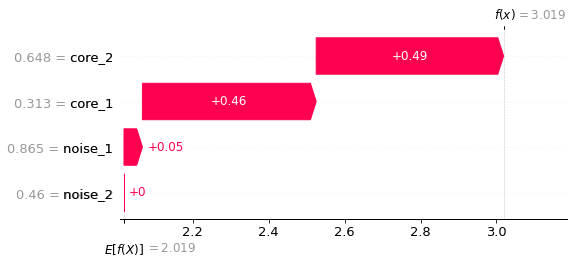

In [1721]:
stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, 20, replace_type="mean", merge_type="mean", 
                                zeroDiag=False, regularization=True, shapley=False, verbose=True)

print(ft_r)

shap.plots.waterfall(sh_e)

In [1716]:
start= time.time()

train_size= train.shape[0]

stationary_values= []

for i in range(train_size):

    stat, ft_r, sh_e= far_explainer(xgb_model, train, labels_train, i, 
                                    replace_type="mean", merge_type="mean", 
                                    zeroDiag=False, regularization=True, shapley=False, verbose=False)
    
    stationary_values.append(stat)
    
base_vector= []
base_vector= [1/(1-p_base_value) for i in range(train_size)]

global_far_exp= to_sh_exp(np.asarray(stationary_values), np.asarray(base_vector), np.asarray(train), 
                          train.columns)

end= time.time()
print("\n--- %s seconds ---" % np.round((end- start), 2))

global_far_exp


--- 103.17 seconds ---


.values =
array([[ 4.87497e-01,  5.12503e-01, -1.17087e-15, -1.17087e-15],
       [-1.84551e-01,  8.05652e-01, -4.69190e-05,  9.75019e-03],
       [ 3.98516e-02,  6.84781e-01,  5.72251e-02, -2.18143e-01],
       ...,
       [ 4.33509e-02,  3.69301e-01, -5.00000e-01,  8.73483e-02],
       [ 5.61272e-03,  9.93764e-01,  4.47819e-04,  1.75220e-04],
       [ 2.16659e-03,  9.97803e-01,  3.05517e-05, -3.79003e-18]])

.base_values =
array([2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884, 2.01884,
       2.01

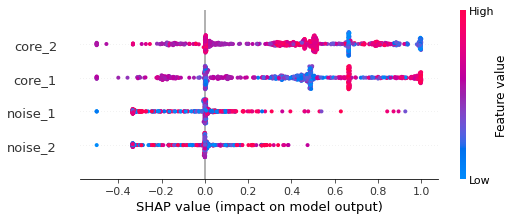

In [1717]:
shap.plots.beeswarm(global_far_exp)

# Magnitude and effect sign

In [1074]:
p_matrix_dif

array([[ 0.00000e+00,  6.65784e-05, -2.98023e-07,  0.00000e+00],
       [-8.75473e-04,  0.00000e+00,  1.78814e-07, -7.70092e-05],
       [-1.90139e-05,  9.23514e-04,  0.00000e+00,  0.00000e+00],
       [-1.74046e-05,  8.47638e-04,  1.31130e-06,  0.00000e+00]])

In [1068]:
p_matrix_mag

array([[0.00000e+00, 6.65784e-05, 2.98023e-07, 0.00000e+00],
       [8.75473e-04, 0.00000e+00, 1.78814e-07, 7.70092e-05],
       [1.90139e-05, 9.23514e-04, 0.00000e+00, 0.00000e+00],
       [1.74046e-05, 8.47638e-04, 1.31130e-06, 0.00000e+00]])

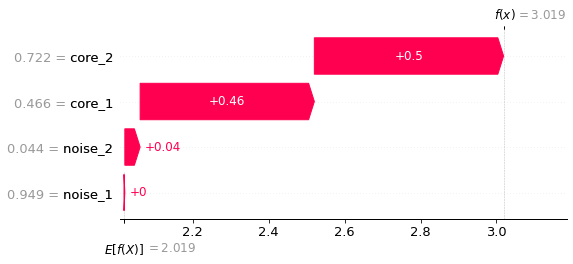

In [1069]:
sh_test= to_sh_exp(stationary_mag, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [1083]:
def effect_direction(n_fts, base, no_i, no_ij):
    
    sig_p_matrix= get_p_matrix_dif(n_fts, no_i, no_ij)
    
    signals= []
    
    for i in range(n_fts):
        total_i= 0
        total_i= np.sum(sig_p_matrix[i])
        
        print(total_i)
        
        if (total_i< 0):
            signals.append(-1)
        else:
            signals.append(1)
            
    return signals

In [1084]:
sigs= effect_direction(num_fts, p_base_value, acc_no_i, acc_no_ij)

sigs

6.628036499023438e-05
-0.000952303409576416
0.0009045004844665527
0.0008315443992614746


[1, -1, 1, 1]

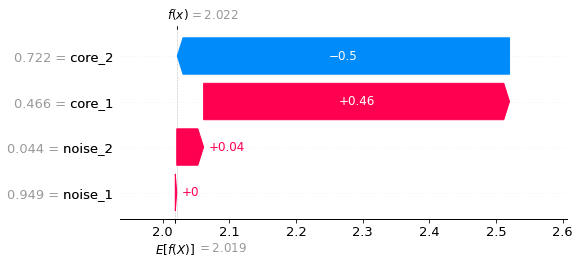

In [1085]:
stationary_sig= stationary_mag* sigs

sh_test= to_sh_exp(stationary_sig, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Ratio

In [1005]:
# test considering p_matrix generated from no_i no_ij ratio NEW VERSION

# get the probability matrix
p_matrix_rt= get_p_matrix_ratio(num_fts, acc_no_i, acc_no_ij, p_base_value, zeroDiag=False)

# get the stationary distribution
stationary_rt= p_matrix_to_stationary_dist(p_matrix_rt)

ft_ranking= pd.Series(stationary_rt, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.250288
noise_1    0.249946
noise_2    0.249936
core_1     0.249830
dtype: float64

In [1007]:
p_matrix_rt

array([[0.9994 , 1.00013, 1.     , 1.     ],
       [0.99827, 1.00127, 1.     , 0.99985],
       [0.99996, 1.00183, 0.99944, 1.     ],
       [0.99997, 1.00168, 1.     , 0.99943]])

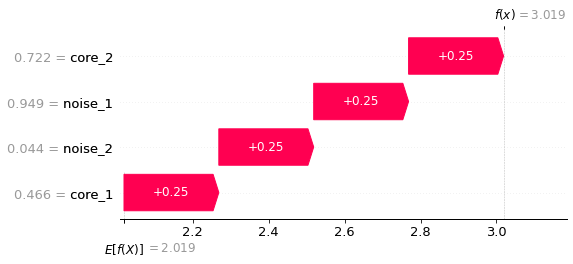

In [1006]:
sh_test= to_sh_exp(stationary_rt, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# ei eij p_matrix div

In [1008]:
# test considering p_matrix generated from ei = fi - f0 and eij = fij - fi

e_i= get_dif_from_original(num_fts, p_base_value, acc_no_i)

e_ij= get_dif_from_original(num_fts, p_base_value, acc_no_ij)

# get the probability matrix
p_matrix_e= get_p_matrix_div(num_fts, e_i, e_ij)

# get the stationary distribution
stationary_e= p_matrix_to_stationary_dist(p_matrix_e)

ft_ranking= pd.Series(stationary_e, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499994
core_1     0.496157
noise_2    0.003839
noise_1    0.000010
dtype: float64

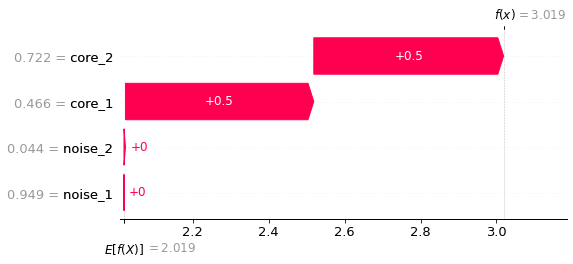

In [1009]:
sh_test= to_sh_exp(stationary_e, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Shapley values i and ij

In [1144]:
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i= get_vector_phi_i(num_fts, p_base_value, acc_no_i)

# get the second row shapley values to fij
sh_phi_ij= get_matrix_phi_ij(num_fts, p_base_value, acc_no_i, acc_no_ij)

# get the probability matrix difference between fij and fi
p_matrix_sh= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=False, zeroDiag=True)

In [1145]:
sh_phi_i

array([ 7.58823e-05, -1.59631e-04,  7.12034e-05,  7.15312e-05])

In [1146]:
sh_phi_ij

array([[ 0.00000e+00,  1.43290e-04,  7.74916e-05,  7.73327e-05],
       [-9.22226e-05,  0.00000e+00, -2.36605e-04, -2.23850e-04],
       [ 7.28127e-05, -5.77108e-06,  0.00000e+00,  7.10941e-05],
       [ 7.29816e-05,  7.31214e-06,  7.14219e-05,  0.00000e+00]])

In [1147]:
p_matrix_sh

array([[ 0.00000e+00,  6.74079e-05,  1.60933e-06,  1.45038e-06],
       [ 6.74079e-05,  0.00000e+00, -7.69744e-05, -6.42190e-05],
       [ 1.60933e-06, -7.69744e-05,  0.00000e+00, -1.09275e-07],
       [ 1.45038e-06, -6.42190e-05, -1.09275e-07,  0.00000e+00]])

In [1148]:
sh_pos, sh_neg= split_pos_neg_p_matrix(num_fts, p_matrix_sh)

sh_pos

array([[0.00000e+00, 6.74079e-05, 1.60933e-06, 1.45038e-06],
       [6.74079e-05, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.60933e-06, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.45038e-06, 0.00000e+00, 0.00000e+00, 0.00000e+00]])

In [1149]:
sh_neg

array([[ 0.00000e+00,  0.00000e+00,  0.00000e+00,  0.00000e+00],
       [ 0.00000e+00,  0.00000e+00, -7.69744e-05, -6.42190e-05],
       [ 0.00000e+00, -7.69744e-05,  0.00000e+00, -1.09275e-07],
       [ 0.00000e+00, -6.42190e-05, -1.09275e-07,  0.00000e+00]])

In [1150]:
# get the stationary distribution - FROM MAG VALUES
stationary_sh= p_matrix_to_stationary_dist(np.abs(p_matrix_sh), version=1) # note the use of abs = mag

ft_ranking= pd.Series(stationary_sh, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.492518
noise_1    0.185798
core_1     0.166377
noise_2    0.155307
dtype: float64

In [1151]:
# get the stationary distribution - POSITIVE VALUES
pos_stationary_sh= p_matrix_to_stationary_dist(sh_pos, version=1)

pos_ft_ranking= pd.Series(pos_stationary_sh, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

core_1     0.500000
core_2     0.478290
noise_1    0.011419
noise_2    0.010291
dtype: float64

In [1152]:
# get the stationary distribution - NEGATIVE VALUES
neg_stationary_sh= p_matrix_to_stationary_dist(sh_neg, version=1)

neg_ft_ranking= pd.Series(neg_stationary_sh, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     0.200023
noise_2    0.199997
noise_1    0.199992
core_2     0.199966
dtype: float64

In [1153]:
st_final= merge_pos_neg_stationary(pos_stationary_sh, neg_stationary_sh, stationary_sh, merge_type="mean")

ft_ranking= pd.Series(st_final, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.256947
core_1     0.155452
noise_1   -0.000925
noise_2   -0.011466
dtype: float64

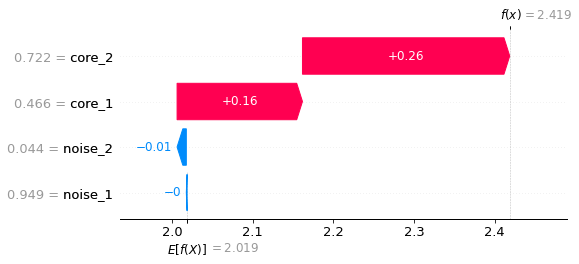

In [1154]:
sh_test= to_sh_exp(st_final, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [1155]:
st_final_reg= ft_ranking_regularization(st_final)

ft_ranking_reg= pd.Series(st_final_reg, index=train.columns).sort_values(ascending=False)
ft_ranking_reg

core_2     0.604880
core_1     0.365949
noise_1   -0.002177
noise_2   -0.026993
dtype: float64

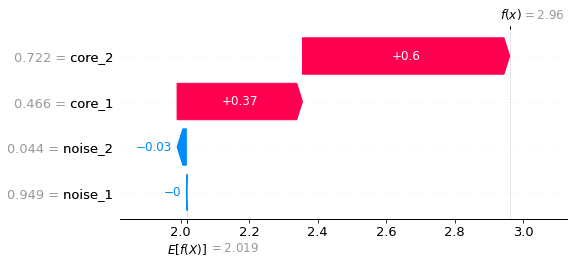

In [1156]:
sh_test= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

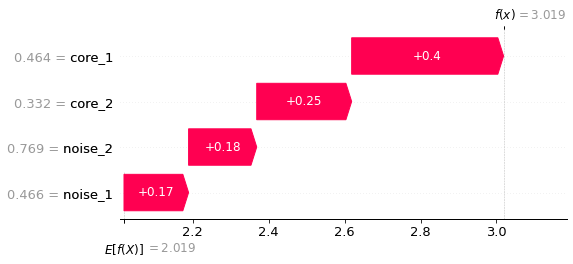

In [1157]:
# target_inst2

# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i2= get_vector_phi_i(num_fts, p_base_value, acc_no_i2)

# get the second row shapley values to fij
sh_phi_ij2= get_matrix_phi_ij(num_fts, p_base_value, acc_no_i2, acc_no_ij2)

# get the probability matrix difference between fij and fi
p_matrix_sh2= get_sh_p_matrix(num_fts, sh_phi_i2, sh_phi_ij2, mag=False, zeroDiag=True)


stationary_sh2= p_matrix_to_stationary_dist(np.abs(p_matrix_sh2), version=1)


sh_pos2, sh_neg2= split_pos_neg_p_matrix(num_fts, p_matrix_sh2)


pos_stationary_sh2= p_matrix_to_stationary_dist(sh_pos2, version=1)

neg_stationary_sh2= p_matrix_to_stationary_dist(sh_neg2, version=1)


st_final= merge_pos_neg_stationary(pos_stationary_sh2, neg_stationary_sh2, stationary_sh2, merge_type="mean")

st_final= ft_ranking_regularization(st_final)

sh_test= to_sh_exp(st_final, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

In [1122]:
target_inst

,core_1,core_2,noise_1,noise_2
42,0.466194,0.721861,0.948764,0.04446


In [1123]:
target_inst2

,core_1,core_2,noise_1,noise_2
845,0.46423,0.331611,0.465974,0.769212


# Regressor version - REMOVE

# Mag

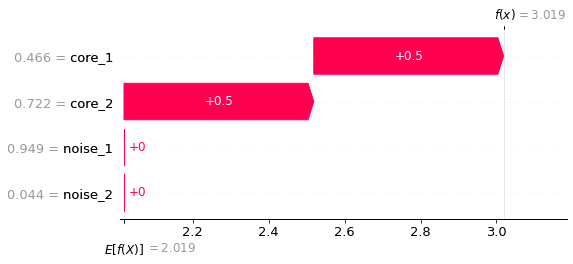

In [1250]:
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag_reg= get_p_matrix_mag(num_fts, acc_no_i_reg, acc_no_ij_reg, zeroDiag=True)

# get the stationary distribution
stationary_mag_reg= p_matrix_to_stationary_dist(p_matrix_mag_reg)

sh_test= to_sh_exp(stationary_mag_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

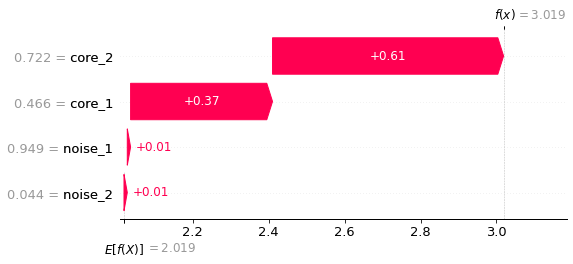

In [1253]:
# Difference and split

# get the probability matrix target_inst
p_matrix_dif_reg= get_p_matrix_dif(num_fts, acc_no_i_reg, acc_no_ij_reg, zeroDiag=True)


pos_reg, neg_reg= split_pos_neg_p_matrix(num_fts, p_matrix_dif_reg)


pos_stationary_reg= p_matrix_to_stationary_dist(pos_reg)

neg_stationary_reg= p_matrix_to_stationary_dist(np.abs(neg_reg)) # note abs use


st_final= merge_pos_neg_stationary(pos_stationary_reg, neg_stationary_reg, stationary_mag_reg, 
                                     merge_type="magmean")

st_final_reg= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_exp)

In [1230]:
stationary_mag_reg

array([5.00000e-01, 5.00000e-01, 2.77556e-17, 2.77556e-17])

In [1231]:
pos_stationary_reg

array([0.14286, 0.5    , 0.14286, 0.14286])

In [1232]:
neg_stationary_reg

array([0.375, 0.25 , 0.125, 0.125])

In [1257]:
p_matrix_dif_reg

array([[ 0.     ,  0.00469,  0.     ,  0.     ],
       [-0.10742,  0.     ,  0.     ,  0.     ],
       [ 0.     ,  0.11211,  0.     ,  0.     ],
       [ 0.     ,  0.11211,  0.     ,  0.     ]])

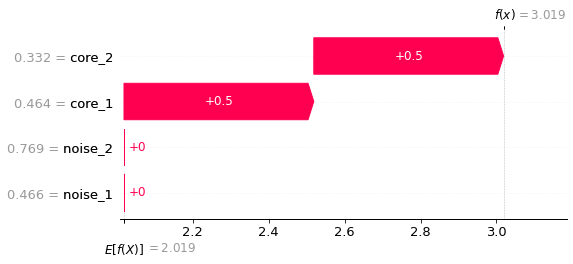

In [1164]:
# target_inst2 --- MAG

# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix_mag_reg2= get_p_matrix_mag(num_fts, acc_no_i_reg2, acc_no_ij_reg2)

# get the stationary distribution
stationary_mag_reg2= p_matrix_to_stationary_dist(p_matrix_mag_reg2)

sh_test= to_sh_exp(stationary_mag_reg2, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_test)

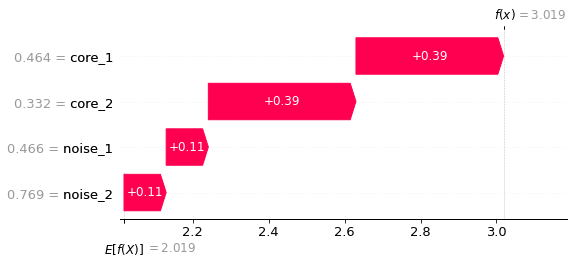

In [1256]:
# Difference and split

# get the probability matrix target_inst2
p_matrix_dif_reg2= get_p_matrix_dif(num_fts, acc_no_i_reg2, acc_no_ij_reg2)


pos_reg2, neg_reg2= split_pos_neg_p_matrix(num_fts, p_matrix_dif_reg2)


pos_stationary_reg2= p_matrix_to_stationary_dist(pos_reg2)

neg_stationary_reg2= p_matrix_to_stationary_dist(np.abs(neg_reg2)) # note abs use


st_final= merge_pos_neg_stationary(pos_stationary_reg2, neg_stationary_reg2, stationary_mag_reg2, 
                                     merge_type="magmean")

st_final_reg= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final_reg, p_base_value, np.asarray(target_inst2)[0], target_inst2.columns)

shap.plots.waterfall(sh_exp)

In [1210]:
stationary_mag_reg2

array([5.00000e-01, 5.00000e-01, 5.55112e-17, 5.55112e-17])

In [1209]:
pos_stationary_reg2

array([0.2, 0.2, 0.2, 0.2])

In [1208]:
neg_stationary_reg2

array([5.00000e-01, 5.00000e-01, 5.55112e-17, 5.55112e-17])

In [1258]:
p_matrix_dif_reg2

array([[ 0.     , -0.87235,  0.     ,  0.     ],
       [-0.10742,  0.     ,  0.     ,  0.     ],
       [-0.00092, -0.76584,  0.     ,  0.     ],
       [-0.00092, -0.76584,  0.     ,  0.     ]])

# Regressor version - ADD

In [1183]:
add_reg_no_i, add_reg_no_ij= add_and_gen_costs_reg(xgb_regre, num_fts, replace_ft_zero, target_inst, 
                                                   verbose=True)

--- 0.2 seconds ---


In [1184]:
add_reg_no_i

[0.06472042, 0.9426754, 0.06563888, 0.06563888]

In [1185]:
add_reg_no_ij

[[0.06472042, 0.9426754, 0.06472042, 0.06472042],
 [0.9426754, 0.9426754, 0.9426754, 0.9426754],
 [0.06472042, 0.9426754, 0.06563888, 0.06563888],
 [0.06472042, 0.9426754, 0.06563888, 0.06563888]]

In [1204]:
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
add_p_matrix_mag= get_p_matrix_mag(num_fts, add_reg_no_i, add_reg_no_ij, remove=False)

# get the stationary distribution
add_stationary_mag= p_matrix_to_stationary_dist(add_p_matrix_mag)

ft_ranking= pd.Series(add_stationary_mag, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499851
core_1     0.143071
noise_1    0.142846
noise_2    0.142846
dtype: float64

In [1187]:
add_p_matrix_mag

array([[0.     , 0.87795, 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.00092, 0.87704, 0.     , 0.     ],
       [0.00092, 0.87704, 0.     , 0.     ]])

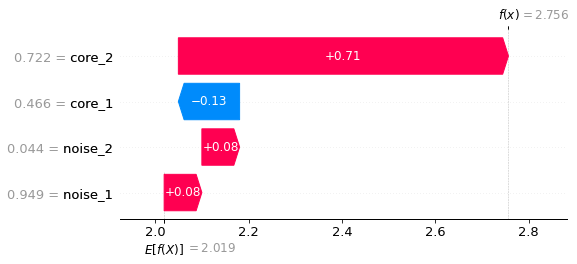

In [1205]:
# get the probability matrix
add_p_matrix_dif= get_p_matrix_dif(num_fts, add_reg_no_i, add_reg_no_ij, remove=False)


add_pos_reg, add_neg_reg= split_pos_neg_p_matrix(num_fts, add_p_matrix_dif)


add_pos_stationary_reg= p_matrix_to_stationary_dist(add_pos_reg)

add_neg_stationary_reg= p_matrix_to_stationary_dist(np.abs(add_neg_reg)) # note abs use


st_final= merge_pos_neg_stationary(add_pos_stationary_reg, add_neg_stationary_reg, add_stationary_mag, 
                                     merge_type="mean")

st_final= ft_ranking_regularization(st_final)

sh_exp= to_sh_exp(st_final, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_exp)

In [1206]:
# test considering p_matrix generated from ei = fi - f0 and eij = fij - fi

f0_targ= xgb_regre.predict(replace_ft)[0]

e_i= get_dif_from_original(num_fts, f0_targ, add_reg_no_i)

e_ij= get_dif_from_original(num_fts, f0_targ, add_reg_no_ij)

# get the probability matrix
add_p_matrix_e= get_p_matrix_mag(num_fts, e_i, e_ij, remove=False)

# get the stationary distribution
add_stationary_e= p_matrix_to_stationary_dist(add_p_matrix_e)

ft_ranking= pd.Series(add_stationary_e, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499851
core_1     0.143071
noise_1    0.142846
noise_2    0.142846
dtype: float64

In [1191]:
add_p_matrix_e

array([[0.     , 0.87796, 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.00092, 0.87704, 0.     , 0.     ],
       [0.00092, 0.87704, 0.     , 0.     ]])

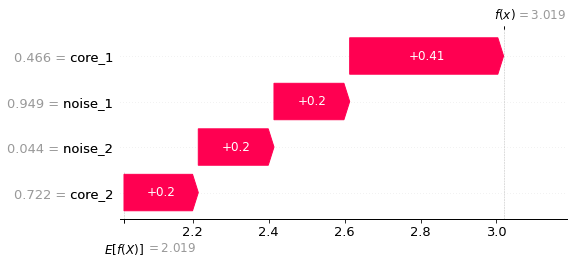

In [1207]:
add_p_matrix_e_dif= get_p_matrix_dif(num_fts, e_i, e_ij, remove=False)


add_sh_pos_e, add_sh_neg_e= split_pos_neg_p_matrix(num_fts, add_p_matrix_e_dif)


add_pos_stationary_sh_e= p_matrix_to_stationary_dist(add_sh_pos_e, version=1)

add_neg_stationary_sh_e= p_matrix_to_stationary_dist(add_sh_neg_e, version=1)


st_final= merge_pos_neg_stationary(add_pos_stationary_sh_e, add_neg_stationary_sh_e, add_stationary_e, 
                                     merge_type="mean")

st_final= ft_ranking_regularization(st_final)

sh_test= to_sh_exp(st_final, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [1196]:
# get the first row shapley values to fi

f0_mean= reg_expected_value(xgb_regre, replace_ft)

add_sh_phi_i= get_vector_phi_i(num_fts, f0_mean, add_reg_no_i)

# get the second row shapley values to fij
add_sh_phi_ij= get_matrix_phi_ij(num_fts, f0_mean, add_reg_no_i, add_reg_no_ij)

# get the probability matrix difference between fij and fi
add_p_matrix_sh= get_sh_p_matrix(num_fts, add_sh_phi_i, add_sh_phi_ij, mag=False, zeroDiag=True)

# get the stationary distribution
add_stationary_sh= p_matrix_to_stationary_dist(np.abs(add_p_matrix_sh), version=1)

ft_ranking= pd.Series(add_stationary_sh, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499651
core_1     0.167015
noise_1    0.166667
noise_2    0.166667
dtype: float64

In [1193]:
add_sh_phi_i

array([-0.21832,  0.00117, -0.21809, -0.21809])

In [1194]:
add_sh_phi_ij

array([[ 0.     , -0.14515, -0.21839, -0.21839],
       [ 0.07434,  0.     ,  0.07426,  0.07426],
       [-0.21816, -0.145  ,  0.     , -0.21809],
       [-0.21816, -0.145  , -0.21809,  0.     ]])

In [1197]:
add_p_matrix_sh

array([[ 0.00000e+00,  7.31629e-02, -7.65380e-05, -7.65380e-05],
       [ 7.31629e-02,  0.00000e+00,  7.30864e-02,  7.30864e-02],
       [-7.65380e-05,  7.30864e-02,  0.00000e+00,  0.00000e+00],
       [-7.65380e-05,  7.30864e-02,  0.00000e+00,  0.00000e+00]])

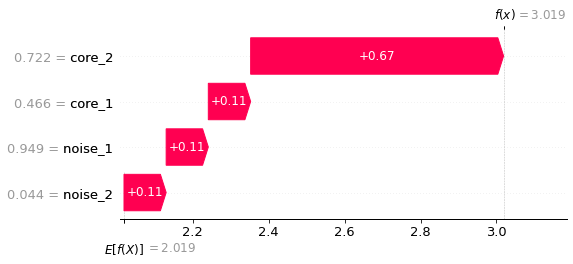

In [1198]:
add_sh_pos, add_sh_neg= split_pos_neg_p_matrix(num_fts, add_p_matrix_sh)


add_pos_stationary_sh= p_matrix_to_stationary_dist(add_sh_pos, version=1)

add_neg_stationary_sh= p_matrix_to_stationary_dist(add_sh_neg, version=1)


st_final= merge_pos_neg_stationary(add_pos_stationary_sh, add_neg_stationary_sh, add_stationary_sh, 
                                     merge_type="mean")

st_final= ft_ranking_regularization(st_final)

sh_test= to_sh_exp(st_final, p_base_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Test using classes "baselines"

In [154]:
# Split the train dataset according its classes
lb_train_a= labels_train.loc[labels_train['target'] == 1]
lb_train_b= labels_train.loc[labels_train['target'] == 0]

train_a= train.loc[lb_train_a.index,:]
train_b= train.loc[lb_train_b.index,:]

In [155]:
# determine a baseline related to each class using the mean
base_a= replace_values(train_a, train_a.columns, num_type='mean')
base_b= replace_values(train_b, train_b.columns, num_type='mean')

lb_base_a= lb_train_a.iloc[0].to_frame().T
lb_base_b= lb_train_b.iloc[0].to_frame().T

print(lb_base_a)
print("Pred base_a sample", xgb_model.predict(base_a))
print("\n")
print(lb_base_b)
print("Pred base_b sample", xgb_model.predict(base_b))
print("\n")
print(target_labl)
print("Pred sample to explain", xgb_model.predict(target_inst))

     target
281     1.0
Pred base_a sample [1]


     target
906     0.0
Pred base_b sample [0]


    target
42     1.0
Pred sample to explain [1]


In [156]:
# get the model behavior after removing i (single ft) and ij (pair) for each baseline

a_no_i, a_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft_zero, base_a, lb_base_a, 
                                      use_preds= True, verbose=True)

b_no_i, b_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft_zero, base_b, lb_base_b, 
                                      use_preds= True, verbose=True)

--- 0.34 seconds ---
--- 0.12 seconds ---


In [157]:
# explaining the baseline - class a - target 1
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
a_sh_phi_i= get_vector_phi_i(num_fts, prob_mean_class, a_no_i)

# get the second row shapley values to fij
a_sh_phi_ij= get_matrix_phi_ij(num_fts, prob_mean_class, a_no_i, a_no_ij)

# get the probability matrix difference between fij and fi
a_p_matrix= get_sh_p_matrix(num_fts, a_sh_phi_i, a_sh_phi_ij, mag=True)

# get the stationary distribution
a_stationary= p_matrix_to_stationary_dist(a_p_matrix)

a_ft_ranking= pd.Series(a_stationary, index=train.columns).sort_values(ascending=False)
a_ft_ranking

core_2     0.642421
core_1     0.128022
noise_1    0.125018
noise_2    0.104538
dtype: float64

In [158]:
# explaining the baseline - class b - target 0
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
b_sh_phi_i= get_vector_phi_i(num_fts, prob_mean_class, b_no_i)

# get the second row shapley values to fij
b_sh_phi_ij= get_matrix_phi_ij(num_fts, prob_mean_class, b_no_i, b_no_ij)

# get the probability matrix difference between fij and fi
b_p_matrix= get_sh_p_matrix(num_fts, b_sh_phi_i, b_sh_phi_ij, mag=True)

# get the stationary distribution
b_stationary= p_matrix_to_stationary_dist(b_p_matrix)

b_ft_ranking= pd.Series(b_stationary, index=train.columns).sort_values(ascending=False)
b_ft_ranking

core_1     0.641738
core_2     0.138045
noise_2    0.124463
noise_1    0.095754
dtype: float64

In [159]:
# explaining the target instance using "neutral values" from entire dataset
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i= get_vector_phi_i(num_fts, prob_mean_class, acc_no_i)

# get the second row shapley values to fij
sh_phi_ij= get_matrix_phi_ij(num_fts, prob_mean_class, acc_no_i, acc_no_ij)

# get the probability matrix difference between fij and fi
p_matrix= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=True)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.639042
noise_1    0.127025
noise_2    0.126198
core_1     0.107735
dtype: float64

In [160]:
from scipy.spatial import distance

# Our sample under explanation (target_inst) is predicted to class 1, such as base_a prediction

# Consider FTi = ft_rank(class(target_inst)) and 
#          base = ft_rank(class(target_inst) == class(baseline))
#
# Then ft_ranking = FTi + abs(FTi-base)/2, if FTi > base
# and  ft_ranking = FTi - abs(FTi-base)/2, if FTi < base

# both vectors must have values [0,1]

def ft_ranking_to_class_importances(target_instance, target_stationary, base_instance, base_stationary, 
                                    w_dist=False, reg_negs=False):
    
    final_stationary= target_stationary.copy()
    
    dist= distance.euclidean(np.asarray(target_instance), np.asarray(base_instance))

    for i in range(len(stationary)):
        targ= target_stationary[i]
        base= base_stationary[i]

        if (targ> base):
            if (w_dist==False):
                final_stationary[i]= targ - (np.abs(targ-base)/2)
            else:
                final_stationary[i]= targ - dist*(np.abs(targ-base)/2)
        else:
            if (w_dist==False):
                final_stationary[i]= targ + (np.abs(targ-base)/2)
            else:
                final_stationary[i]= targ + dist*(np.abs(targ-base)/2)
            
    if (reg_negs==True):
        final_stationary= ft_ranking_regularization(final_stationary)
        
    return final_stationary

In [161]:
# We have class(target_inst)==1, class(base_a)==1 and class(base_b)==0

final_stationary= ft_ranking_to_class_importances(target_inst, stationary, base_a, a_stationary)

final_ft_ranking= pd.Series(final_stationary, index=train.columns).sort_values(ascending=False)
final_ft_ranking

core_2     0.640732
noise_1    0.126022
core_1     0.117879
noise_2    0.115368
dtype: float64

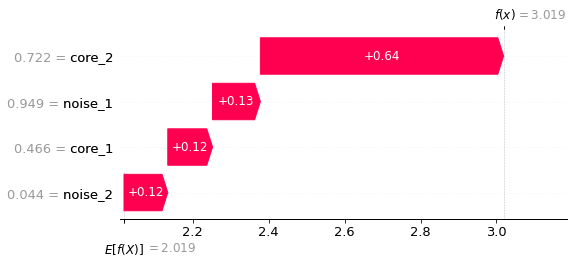

In [162]:
sh_test= to_sh_exp(final_stationary, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [163]:
reg_final_ft_ranking= pd.Series(ft_ranking_regularization(final_stationary), 
                                index=train.columns).sort_values(ascending=False)
reg_final_ft_ranking

core_2     0.640732
noise_1    0.126022
core_1     0.117879
noise_2    0.115368
dtype: float64

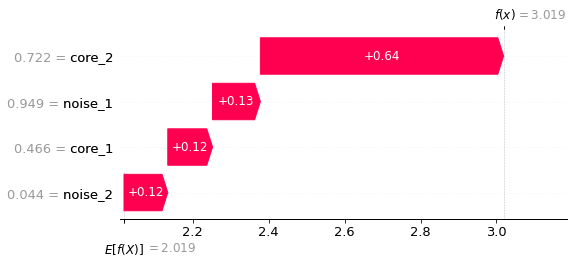

In [164]:
sh_test= to_sh_exp(ft_ranking_regularization(final_stationary), exp_value, np.asarray(target_inst)[0], 
                   target_inst.columns)

shap.plots.waterfall(sh_test)

# Using divergence

In [165]:
# baseline - class a - target 1
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
a_p_matrix= get_p_matrix_div(num_fts, a_no_i, a_no_ij)

# get the stationary distribution
a_stationary= p_matrix_to_stationary_dist(a_p_matrix)

a_ft_ranking= pd.Series(a_stationary, index=train.columns).sort_values(ascending=False)
a_ft_ranking

core_2     0.499979
noise_2    0.499418
noise_1    0.000429
core_1     0.000174
dtype: float64

In [166]:
# baseline - class b - target 0
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
b_p_matrix= get_p_matrix_div(num_fts, b_no_i, b_no_ij)

# get the stationary distribution
b_stationary= p_matrix_to_stationary_dist(b_p_matrix)

b_ft_ranking= pd.Series(b_stationary, index=train.columns).sort_values(ascending=False)
b_ft_ranking

core_1     0.334826
core_2     0.329540
noise_2    0.329506
noise_1    0.006128
dtype: float64

In [167]:
# explaining the target instance using "neutral values" from entire dataset
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
p_matrix= get_p_matrix_div(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499981
core_1     0.451667
noise_1    0.047005
noise_2    0.001347
dtype: float64

In [168]:
# We have class(target_inst)==1, class(base_a)==1 and class(base_b)==0

final_stationary= ft_ranking_to_class_importances(target_inst, stationary, base_a, a_stationary)

final_ft_ranking= pd.Series(final_stationary, index=train.columns).sort_values(ascending=False)
final_ft_ranking

core_2     0.499980
noise_2    0.250382
core_1     0.225920
noise_1    0.023717
dtype: float64

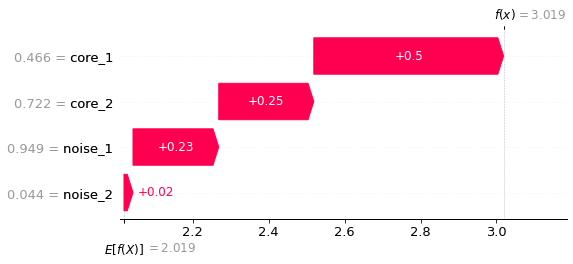

In [169]:
sh_test= to_sh_exp(final_ft_ranking, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [179]:
# get the model behavior after removing process of i (single ft) and ij (pair)

num_fts= len(x_syn.columns)

acc_no_i, acc_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft, target_inst, target_labl, 
                                          use_preds= True, verbose=True)

--- 0.3 seconds ---


In [180]:
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i= get_vector_phi_i(num_fts, p_base_value, acc_no_i)

# get the second row shapley values to fij
sh_phi_ij= get_matrix_phi_ij(num_fts, p_base_value, acc_no_i, acc_no_ij)

# get the probability matrix difference between fij and fi
p_matrix= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=True)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.659479
core_1     0.126751
noise_2    0.107020
noise_1    0.106750
dtype: float64

In [181]:
# We have class(target_inst)==1, class(base_a)==1 and class(base_b)==0

final_stationary= ft_ranking_to_class_importances(target_inst, stationary, base_b, b_stationary)

final_ft_ranking= pd.Series(final_stationary, index=train.columns).sort_values(ascending=False)
final_ft_ranking

core_2     0.494510
core_1     0.230788
noise_2    0.218263
noise_1    0.056439
dtype: float64

In [182]:
sh_phi_i

array([ 2.65241e-06, -2.24887e-03,  0.00000e+00,  5.96046e-08])

In [183]:
acc_no_i

[0.5049132108688354,
 0.49590712785720825,
 0.5049026012420654,
 0.5049028396606445]

In [184]:
sh_phi_ij

array([[-8.76918e-04, -8.84031e-04,  3.53654e-06,  3.57628e-06],
       [-3.13555e-03, -9.13433e-03, -2.99849e-03, -3.00029e-03],
       [ 8.84136e-07, -7.49623e-04, -7.48719e-04,  1.98682e-08],
       [ 9.83477e-07, -7.51361e-04,  7.94729e-08, -7.50298e-04]])

In [185]:
print(acc_no_ij)

[[0.5049132108688354, 0.4950900673866272, 0.5049132108688354, 0.5049135684967041], [0.4950900673866272, 0.49590712785720825, 0.49590712785720825, 0.49589645862579346], [0.5049132108688354, 0.49590712785720825, 0.5049026012420654, 0.5049028396606445], [0.5049135684967041, 0.49589645862579346, 0.5049028396606445, 0.5049028396606445]]


In [186]:
p_matrix_dif= get_sh_p_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=False)
p_matrix_dif

array([[ 2.65241e-06, -8.86684e-04,  8.84136e-07,  9.23872e-07],
       [-8.86684e-04, -2.24887e-03, -7.49623e-04, -7.51421e-04],
       [ 8.84136e-07, -7.49623e-04,  0.00000e+00,  1.98682e-08],
       [ 9.23872e-07, -7.51421e-04,  1.98682e-08,  5.96046e-08]])

In [187]:
p_matrix

array([[2.65241e-06, 8.86684e-04, 8.84136e-07, 9.23872e-07],
       [8.86684e-04, 2.24887e-03, 7.49623e-04, 7.51421e-04],
       [8.84136e-07, 7.49623e-04, 0.00000e+00, 1.98682e-08],
       [9.23872e-07, 7.51421e-04, 1.98682e-08, 5.96046e-08]])

In [188]:
signal_lin_p_matrix= np.zeros(num_fts)

for i in range(num_fts):
    signal_lin_p_matrix[i]= np.prod(p_matrix_dif[i])
    
signal_ft= np.zeros(num_fts)
    
for i in range(num_fts):
    signal_ft[i]= signal_lin_p_matrix[i]
    
    for j in range(num_fts):
        if (i!=j):
            signal_ft[i]= signal_ft[i]*p_matrix_dif[j][i]
    
signal_ft

array([ 1.39136e-36, -5.60988e-22,  0.00000e+00,  1.13393e-41])

# Tests using LIME

In [189]:
import lime
import lime.lime_tabular

explainer= lime.lime_tabular.LimeTabularExplainer(np.asarray(train), feature_names=np.asarray(x_syn.columns), 
                                                  class_names= np.asarray([0,1]), verbose=False, 
                                                  mode='classification', discretize_continuous=False)

In [190]:
exp= explainer.explain_instance(np.asarray(target_inst)[0], xgb_model.predict_proba, num_features=4, 
                                top_labels=1)

exp.show_in_notebook(show_table=True, show_all=True)

In [191]:
print('Element id: %d' % target_pos)
print('Probability(0 class) =', xgb_model.predict_proba(target_inst)[0,0])
print('True class: %s' % int(np.asarray(target_labl)[0]))

Element id: 9
Probability(0 class) = 0.5049026
True class: 0


# New attempt - considering top and bottom 1/n elements

In [206]:
def sh_values_top_bottom(model, n_fts, exp_sample, exp_label, replace_ft, verbose=False):
    start= time.time()
    
    f_0= model.predict(replace_ft)[0]
    
    f_x= model.predict(exp_sample)[0]
    
    f_i, f_ij= add_and_gen_costs_reg(model, n_fts, replace_ft, exp_sample, verbose)
    
    f_no_i= []
    
    for i in range(n_fts):  # add and predict process to get gains/losses
        
        # replace_ft contains "neutral" values to each feature, now we add all the features from x_to_exp
        # except the i-th value from replace_ft one by one the assess gain/loses
        x_to_exp_no_i= exp_sample.copy()
        x_to_exp_no_i.loc[:,x_to_exp_no_i.columns[i]]= replace_ft.iloc[0,i]
        
        f_no_i.append(model.predict(x_to_exp_no_i)[0])
        
    phi_i= []
    
    for i in range(n_fts):
        phi_i.append((1/ n_fts)*(f_i[i]- f_0))
        
        for j in range(n_fts):
            top= 0
            btm= 0
            
            if (i!=j):
                top= (1/(n_fts*(n_fts-1)))*(2*f_ij[i][j]- f_i[i]- f_i[j])   
            elif (i==j):
                btm= (1/ n_fts)*(f_x- f_no_i[i])
                
            phi_i[i]= phi_i[i] + top + btm
            
            
    phi_ij= (1/ n_fts)*(f_ij- f_0)
    
    for i in range(n_fts):
        for j in range(n_fts):
            
            if (i!= j):
                x_to_exp_no_ij= exp_sample.copy()
                x_to_exp_no_ij.loc[:,x_to_exp_no_ij.columns[i]]= replace_ft.iloc[0,i]
                x_to_exp_no_ij.loc[:,x_to_exp_no_ij.columns[j]]= replace_ft.iloc[0,j]

                f_no_ij= model.predict(x_to_exp_no_ij)[0]
                
                phi_ij[i][j]= phi_ij[i][j] + (1/ n_fts)*(f_x - f_no_ij)
            else:
                phi_ij[i][i]= 0
                
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
        
    return phi_i, phi_ij

In [207]:
new_phi_i, new_phi_ij= sh_values_top_bottom(reg, num_fts, target_inst, target_labl, replace_ft_zero)
new_phi_ij

array([[ 0.     , -0.00046, -0.00046, -0.00046],
       [-0.00046,  0.     ,  0.     ,  0.     ],
       [-0.00046,  0.     ,  0.     ,  0.     ],
       [-0.00046,  0.     ,  0.     ,  0.     ]], dtype=float32)

In [208]:
# get the probability matrix difference between fij and fi
p_matrix= get_sh_p_matrix(num_fts, new_phi_i, new_phi_ij, mag=True)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix,version=1)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.555556
noise_1    0.148148
core_2     0.148148
noise_2    0.148148
dtype: float64

In [209]:
p_matrix

array([[6.88842e-04, 2.29614e-04, 2.29614e-04, 2.29614e-04],
       [3.82690e-04, 7.65380e-05, 7.65380e-05, 7.65380e-05],
       [3.82690e-04, 7.65380e-05, 7.65380e-05, 7.65380e-05],
       [3.82690e-04, 7.65380e-05, 7.65380e-05, 7.65380e-05]])

In [210]:
new_phi_i

[-0.0006888415664434433,
 -7.653795182704926e-05,
 -7.653795182704926e-05,
 -7.653795182704926e-05]

# Feature Attribution using PageRank - methods

In [ ]:
def run_lib_pr(graph_matrix, ft_names, iteration= 100, damping_factor= 0.85, tolerance= 1.0e-6):
    
    num_fts= graph_matrix.shape[0]
    
    D= nx.DiGraph()

    for i in range(num_fts):
        for j in range(num_fts):
            if (i!= j):
                D.add_weighted_edges_from([(ft_names[i],ft_names[j],graph_matrix[i,j])])
    
                
    pRank= pd.Series(nx.pagerank(D, max_iter=iteration, alpha=damping_factor, tol=tolerance))

    return pRank.sort_values(ascending=False)

In [ ]:
# using my PR to compare results
def run_my_pr(graph_matrix, ft_names, iteration= 100, damping_factor= 0.95, tolerance= 1.0e-6):
    
    file_path= 'datasets/FAR_data.txt'
    
    num_fts= graph_matrix.shape[0]

    f= open(file_path, 'w')

    for i in range(num_fts):
        for j in range(num_fts):
            line= (str(int(i)) + ',' + str(int(j)) + ',' + str(graph_matrix[i,j]) + '\n')
            f.write(line)

    f.close()

    graph= gpr.init_graph(file_path)

    myPRank= pd.Series(pr.run_PageRank(graph, iteration=iteration, damping_factor=damping_factor, 
                                       tolerance=tolerance))
    myPRank= myPRank.sort_values(ascending=False)
    
    ids_names= ft_names[(myPRank.index).astype(int)]

    myPRank.index= ids_names

    return myPRank

# OLD --- Tests using the Titanic dataset ---

# Data loading and preprocessing

In [ ]:
#!kaggle competitions download -c titanic

In [ ]:
ds= zf.ZipFile('datasets/titanic.zip')

train_data= pd.read_csv(ds.open('train.csv'))
test_data= pd.read_csv(ds.open('test.csv'))

train_data.shape, test_data.shape

In [ ]:
train_data.head()

In [ ]:
test_data.head()

In [ ]:
X_all= pd.concat([train_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']],
                   test_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]]).set_index('PassengerId')

y_train= train_data[['PassengerId','Survived']].set_index('PassengerId')['Survived']

X_all

In [ ]:
numeric_columns= ['Age','SibSp','Parch','Fare']
categor_columns= list(filter(lambda x:x not in numeric_columns,X_all.columns))

X_train= X_all.iloc[:len(train_data),:].copy()
X_test= X_all.iloc[len(train_data):].copy()

In [ ]:
# in this case we'll only use X_train df because X_test is not labeled

In [ ]:
X_train= pre_proc_fillna_num_fts(X_train,numeric_columns,num_type='median')

X_train= pre_proc_fillna_cat_fts(X_train,categor_columns,cat_type='mode')

X_train

In [ ]:
# one-hot encoding the qualitative features
X_train_ohe= pd.get_dummies(X_train,columns=categor_columns)

X_train_ohe.head()

In [ ]:
y_train.head()

In [ ]:
# normalize the numeric columns of dataframe with each value between 0 and 1
X_train= normalize_selected(X_train, numeric_columns)
X_train_ohe= normalize_selected(X_train_ohe, numeric_columns)

# ML model setup

In [ ]:
train, test, labels_train, labels_test= train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)

#train, test, labels_train, labels_test= train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)
#xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)

#train, test, labels_train, labels_test= train_test_split(X_train,y_train,train_size=0.80,random_state=1234)
#cat_fts= [train.columns.to_list().index(col) for col in categor_columns]
#ctb_model= CatBoostClassifier(cat_features=cat_fts,silent=True)

# --- Run global modeling (no retraining) ---

In [ ]:
repeat_train= 1

num_fts= len(train.columns)

In [ ]:
# train the ML model and get the accuracy using the entire feature set
acc_all_fts= train_model_get_acc_mean(rf, train, test, labels_train, labels_test, repeat_train)

# rf is the model trained

acc_all_fts

In [ ]:
# values to "remove" (entire dataset)
replace_ft= replace_values(X_train_ohe, numeric_columns, num_type='mean', cat_type='median')

replace_ft

In [ ]:
# calculates "transition" costs removing columns from the feature set using a trained model

acc_no_i, acc_no_ij= remove_and_return_costs(rf, replace_ft, test, labels_test, True)

In [ ]:
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Run local modeling (k-NN version, no retraining) ---

In [ ]:
# the instance to be explained (from train dataset)
target_index= 1

target_inst= train.loc[train.index== target_index]
target_labl= labels_train.loc[labels_train.index== target_index]

In [ ]:
# calculates "transition" costs removing columns from a target instance using a trained model
# target instance is supported by neighb_size percent nearest neighbors of test dataset

acc_no_i, acc_no_ij= knn_remove_and_return_costs(rf, replace_ft, test, labels_test, target_inst, target_labl,
                                                 neighb_size= 0.5, verbose=True)

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# TARGET INSTANCE TO EXPLAIN ITS FEATURES

X_all.loc[X_all.index== target_index]

In [ ]:
target_label

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Run PageRank approach (k-NN local version, no retraining) ---

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= p_matrix_to_row_stochastic_matrix(p_matrix4)

In [ ]:
run_lib_pr(st_matrix1, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix2, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix3, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix4, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix1, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix2, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix3, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix4, X_train_ohe.columns)

# --- Run local modeling (k-Fold version, no retraining) ---

In [ ]:
# calculates "transition" costs removing columns from a target instance using a trained model
# target instance is supported by neighb_size percent nearest neighbors of test dataset applied in a kfolding way

acc_no_i, acc_no_ij= knnfold_remove_and_return_costs(rf, replace_ft, test, labels_test, 
                                                     target_inst, target_labl, neighb_size= 0.5, 
                                                     k_folds=10, verbose=True)

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# TARGET INSTANCE TO EXPLAIN ITS FEATURES

X_all.loc[X_all.index== target_index]

In [ ]:
target_label

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Global version with retraining ---

In [ ]:
repeat_train= 5

acc_all_fts= train_model_get_acc_mean(rf, train, test, labels_train, labels_test, repeat_train)

acc_no_i, acc_no_ij= remove_and_retrain(rf, replace_ft, train, test, labels_train, labels_test,
                                        repeat_train, verbose=True)

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# Misc

In [ ]:
eigval, eigvec= eigs(st_matrix3.T, k=1, which='LM')
eigval

In [ ]:
f= open('datasets/FAR_data.txt', 'w')

for i in range(num_fts):
    for j in range(num_fts):
        line= (str(i) + ',' + str(j) + ',' + str(p_matrix1[i][j]) + '\n')
        f.write(line)
        
f.close()